# Notebook #4 — Augmentacja uwzgledniajaca rezimy pracy (cluster-aware) dla estymacji `pm`

## 0. Cel notebooka i pytania badawcze

Notebook realizuje etap **cluster-aware augmentation** w potoku: EDA (NB#1) -> odkrywanie rezimow i segmentacja (NB#2) -> klasteryzacja segmentow (NB#3) -> **augmentacja (NB#4)** -> regresja i ocena `pm`.

**Hipoteza badawcza.** Augmentacja warunkowana rezimami pracy zidentyfikowanymi metodami uczenia nienadzorowanego pozwala generowac syntetyczne obserwacje wielowymiarowych szeregow czasowych PMSM, ktore zachowuja lokalne wlasciwosci danych i moga poprawic zdolnosc generalizacji modelu estymacji temperatury magnesow trwalych `pm`. Hipoteza jest **testowana**, a nie zalozona.

**Pytania badawcze.**
1. Czy dane syntetyczne odtwarzaja rozklady brzegowe, zaleznosci czasowe i zaleznosci miedzykanalowe rzeczywistych danych treningowych?
2. Czy augmentacja poprawia jakosc estymacji `pm` na niezmienionym, rzeczywistym zbiorze testowym?
3. Czy warunkowanie augmentacji na klastrach (rezimach) daje mierzalna korzysc wzgledem augmentacji globalnej **przy tej samej liczbie obserwacji syntetycznych**?
4. Czy augmentacja generatywna (TimeGAN) przewaza nad augmentacja klasyczna?
5. Czy zwiekszanie udzialu danych syntetycznych poprawia wyniki monotonicznie?

**Zasada nadrzedna.** Augmentowany jest wylacznie zbior treningowy. Zbiory walidacyjny i testowy pozostaja rzeczywiste, niezmienione i calkowicie wylaczone z estymacji jakichkolwiek parametrow augmentacji (rozdz. 3 i 17).

## 1. Importy i konfiguracja

Pojedyncza sekcja konfiguracyjna; dalsze sekcje nie wprowadzaja stalych liczbowych. `FAST_MODE=True` pozwala zweryfikowac caly potok przy skroconym treningu GAN; pelny eksperyment uzyskuje sie wylacznie zmiana konfiguracji.

In [2]:
import os
!git clone https://github.com/laryskasagan/AUGUMENTATION.git /content/proj
os.chdir('/content/proj')

from pathlib import Path
print("cwd:", os.getcwd())
for p in ["regime_discovery_outputs/segments_series_index.csv",
          "clustering_outputs/cluster_labels.csv",
          "eda_outputs/profile_split.csv",
          "augmentation_outputs/segments_all_channels.npy"]:
    print("OK     " if Path(p).exists() else "BRAK   ", p)

Cloning into '/content/proj'...
remote: Enumerating objects: 145, done.
remote: Total 145 (delta 0), reused 0 (delta 0), pack-reused 145 (from 1)
Receiving objects: 100% (145/145), 59.33 MiB | 16.87 MiB/s, done.
Resolving deltas: 100% (6/6), done.
cwd: /content/proj
OK      regime_discovery_outputs/segments_series_index.csv
OK      clustering_outputs/cluster_labels.csv
OK      eda_outputs/profile_split.csv
OK      augmentation_outputs/segments_all_channels.npy


In [3]:
import gc, json, random, time, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors

# --- sciezki wejsciowe/wyjsciowe ---
NB2_DIR = Path("regime_discovery_outputs")     # segmentacja (NB#2)
NB3_DIR = Path("clustering_outputs")           # klasteryzacja (NB#3)
EDA_DIR = Path("eda_outputs")
RAW_PATH = Path("dataset/raw/measures_v2.csv")
OUT_DIR = Path("augmentation_outputs"); (OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

# --- powtarzalnosc ---
RANDOM_STATE = 42
FAST_MODE = False                              # skrocony trening GAN (walidacja potoku)

# --- dane ---
SAMPLING_FREQUENCY = 2.0                       # Hz (NB#1/NB#2)
TARGET = "pm"
CHANNELS = ["u_d", "u_q", "i_d", "i_q", "motor_speed", "torque",
            "coolant", "ambient", "pm", "stator_yoke", "stator_tooth", "stator_winding"]
# Wejscia modelu regresyjnego: elektryczne, mechaniczne i chlodzenie. Temperatury stojana
# pominieto celowo - w zastosowaniu docelowym sa to rowniez nieobserwowane stany termiczne,
# a ich uzycie czyni zadanie estymacji pm trywialnym.
SELECTED_FEATURES = ["u_d", "u_q", "i_d", "i_q", "motor_speed", "torque", "coolant", "ambient"]
EWMA_SPANS = (8, 32)                           # wykladnicze usrednianie w obrebie segmentu

# --- klasteryzacja z NB#3 ---
SELECTED_CLUSTERING_METHOD = "kmeans"          # uzasadnienie w rozdz. 2
ALT_CLUSTERING_METHOD = "gmm"                  # analiza wrazliwosci (rozdz. 15)

# --- augmentacja ---
FIXED_SEQUENCE_LENGTH = 128                    # = RESAMPLE_LEN z NB#2
AUGMENTATION_RATIOS = (0.25, 0.5, 1.0)         # klasyczne warianty
GAN_RATIOS = (0.5, 1.0)                        # warianty generatywne (ograniczenie kosztu)
HYBRID_RATIO = 1.0
RATIO_REFERENCE = 1.0                          # wariant odniesienia dla walidacji jakosci
NOISE_SCALE = 0.5                              # udzial skladowej HF w jitterze
RATIO_CAP = 2.0                                # ograniczenie wzmocnienia malych klastrow
INTERP_LAMBDA = (0.25, 0.75)                   # zakres wagi interpolacji segmentow
K_NEIGHBORS = 5                                # liczba sasiadow przy interpolacji

# --- TimeGAN ---
LATENT_DIM = 12
HIDDEN_DIM = 24
NUM_LAYERS = 2
BATCH_SIZE = 64
GAN_LR = 1e-3
GAMMA_SUPERVISED = 10.0                        # waga straty nadzorowanej (dynamika krokowa)
GAN_EPOCHS = dict(ae=150, sup=100, joint=300) if FAST_MODE else dict(ae=150, sup=100, joint=300)
TRAIN_UNCONDITIONAL_GAN = True                 # odpowiednik GLOBAL_AUG dla metody generatywnej

# --- model downstream (identyczny dla wszystkich wariantow) ---
MODEL_PARAMS = dict(max_iter=250, learning_rate=0.08, max_leaf_nodes=31,
                    min_samples_leaf=40, l2_regularization=1.0,
                    early_stopping=False, random_state=RANDOM_STATE)

random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
RNG = np.random.default_rng(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

print(f"device={DEVICE} | FAST_MODE={FAST_MODE} | GAN_EPOCHS={GAN_EPOCHS}")
print(f"torch={torch.__version__} | kanaly={len(CHANNELS)} | L={FIXED_SEQUENCE_LENGTH}")

device=cuda | FAST_MODE=False | GAN_EPOCHS={'ae': 150, 'sup': 100, 'joint': 300}
torch=2.11.0+cu128 | kanaly=12 | L=128


## 2. Wczytanie wynikow NB#3

Wejsciem sa **wylacznie** artefakty NB#2 (granice segmentow, podzial profili) i NB#3 (etykiety klastrow, konfiguracja). Segmentacja, podzial i klasteryzacja **nie sa** powtarzane. Weryfikowana jest spojnosc `segment_id` oraz flag podzialu miedzy plikami obu notebookow; niespojnosc przerywa wykonanie z komunikatem o koniecznosci ponownego uruchomienia NB#3 (artefakty klasteryzacji musza odpowiadac aktualnym segmentom).

**Wybor metody klasteryzacji.** Z tabeli porownawczej NB#3 wybrano `kmeans`: najwyzsza stabilnosc (ARI po resamplingu TRAIN), brak obserwacji szumowych i pelne pokrycie segmentow. HDBSCAN uzyskuje wyzszy Silhouette, lecz klasyfikuje wiekszosc segmentow jako szum, co uniemozliwia zdefiniowanie polityki augmentacji dla calego zbioru treningowego; GMM ma istotnie nizsza stabilnosc. Ograniczeniem wyboru jest mala liczba klastrow (K=2), co zmniejsza granularnosc warunkowania - wplyw tego ograniczenia badany jest w rozdz. 15 przy uzyciu etykiet alternatywnych.

In [4]:
seg = pd.read_csv(NB2_DIR / "segments_features.csv")
idx = pd.read_csv(NB2_DIR / "segments_series_index.csv")
labels = pd.read_csv(NB3_DIR / "cluster_labels.csv")
cfg2 = json.load(open(NB2_DIR / "segmentation_config.json"))
cfg3 = json.load(open(NB3_DIR / "clustering_config.json"))
split_df = pd.read_csv(EDA_DIR / "profile_split.csv")
comparison_nb3 = pd.read_csv(NB3_DIR / "clustering_comparison.csv")

# Kontrola spojnosci artefaktow NB#2 <-> NB#3 (identycznosc i kolejnosc segmentow oraz flag podzialu).
SCHEMA_OK = (len(labels) == len(idx)
             and (labels["segment_id"].values == idx["segment_id"].values).all()
             and (labels["in_train"].values == idx["in_train"].values).all())
if not SCHEMA_OK:
    raise RuntimeError(
        "Artefakty NB#3 (cluster_labels.csv) nie odpowiadaja aktualnym segmentom NB#2. "
        "Wymagane ponowne uruchomienie NB#3 na aktualnym pliku segments_series_index.csv.")

LABEL_COL = f"label_{SELECTED_CLUSTERING_METHOD}"
assert LABEL_COL in labels.columns, f"Brak kolumny {LABEL_COL} w artefaktach NB#3"
assert int(cfg2["RESAMPLE_LEN"]) == FIXED_SEQUENCE_LENGTH, "Niezgodnosc dlugosci reprezentacji z NB#2"

# Jedna tabela metadanych segmentow (bez duplikowania kolumn cech NB#2).
meta = idx.merge(labels[["segment_id", LABEL_COL, f"label_{ALT_CLUSTERING_METHOD}"]], on="segment_id")
meta = meta.rename(columns={LABEL_COL: "cluster_id", f"label_{ALT_CLUSTERING_METHOD}": "cluster_id_alt"})
meta["duration_s"] = (meta["end_sample"] - meta["start_sample"]) / SAMPLING_FREQUENCY
meta["is_synthetic"] = False
meta["augmentation_method"] = "none"

TRAIN_ROWS = np.flatnonzero((meta["split"] == "train").values)
VAL_ROWS = np.flatnonzero((meta["split"] == "val").values)
TEST_ROWS = np.flatnonzero((meta["split"] == "test").values)
CLUSTERS = np.sort(meta.loc[TRAIN_ROWS, "cluster_id"].unique())
N_CLUSTERS = len(CLUSTERS)

print(comparison_nb3[["Method", "K", "FeatureSilhouette", "StabilityARI", "OpHomogeneity", "Noise%"]]
      .to_string(index=False))
print(f"\nSegmenty: {len(meta)} | train={len(TRAIN_ROWS)} val={len(VAL_ROWS)} test={len(TEST_ROWS)}")
print(f"Metoda: {SELECTED_CLUSTERING_METHOD} | klastry TRAIN: {list(CLUSTERS)}")
print("Dlugosc segmentow [s]: min=%.0f mediana=%.0f max=%.0f"
      % (meta.duration_s.min(), meta.duration_s.median(), meta.duration_s.max()))

      Method  K  FeatureSilhouette  StabilityARI  OpHomogeneity  Noise%
      kmeans  2              0.253         0.981          1.441     0.0
         gmm  3              0.146         0.494          1.443     0.0
     hdbscan  3              0.348         0.740          1.056    64.4
kmedoids_dtw  2              0.108         0.724          1.201     0.0

Segmenty: 1118 | train=734 val=190 test=194
Metoda: kmeans | klastry TRAIN: [np.int64(0), np.int64(1)]
Dlugosc segmentow [s]: min=120 mediana=260 max=12190


## 3. Kontrola podzialu train/test i leakage

Podzial profili pochodzi z NB#1 (`profile_split.csv`, GroupShuffleSplit 70/15/15) i nie jest modyfikowany. Kontrolowana jest rozlacznosc `profile_id` miedzy zbiorami oraz zgodnosc flag podzialu z NB#2 i NB#3. Skrot (hash) rzeczywistego zbioru testowego wyznaczany jest przed augmentacja i weryfikowany w rozdz. 17.

In [5]:
split_map = dict(zip(split_df["profile_id"].astype(int), split_df["split"]))
PROF = {s: set(meta.loc[meta.split == s, "profile_id"]) for s in ("train", "val", "test")}

assert not (PROF["train"] & PROF["val"]) and not (PROF["train"] & PROF["test"]) \
    and not (PROF["val"] & PROF["test"]), "Wyciek: profil w wiecej niz jednym zbiorze"
assert all(split_map[int(p)] == s for s in PROF for p in PROF[s]), "Podzial niezgodny z NB#1"
assert set(cfg2["train_ids"]) == PROF["train"] and set(cfg2["test_ids"]) == PROF["test"], \
    "Podzial niezgodny z konfiguracja NB#2"

AUDIT = {}
AUDIT["podzial_profili_zgodny_z_NB1"] = True
AUDIT["profile_train_val_test_rozlaczne"] = True
AUDIT["etykiety_klastrow_pochodza_z_NB3"] = LABEL_COL in labels.columns and SCHEMA_OK
print(f"train: {len(PROF['train'])} profili | val: {len(PROF['val'])} | test: {len(PROF['test'])}")
print("profile_id TEST:", sorted(PROF["test"]))

train: 47 profili | val: 11 | test: 11
profile_id TEST: [2, 6, 12, 14, 20, 26, 43, 45, 56, 59, 65]


## 4. Charakterystyka klastrow przed augmentacja

Liczebnosci klastrow wyznaczono **wylacznie na zbiorze treningowym**. Polityka augmentacji: klastry mniej liczne otrzymuja proporcjonalnie wiecej obserwacji syntetycznych wedlug reguly

`augmentation_ratio(c) = base_ratio * min(RATIO_CAP, sqrt(n_ref / n_c))`,

gdzie `n_ref` to mediana liczebnosci klastrow TRAIN. Pierwiastek ogranicza sile korekty (rownowaga miedzy uzupelnianiem klastrow rzadkich a zachowaniem empirycznego rozkladu rezimow), a `RATIO_CAP` zapobiega dominacji danych syntetycznych w najmniejszym klastrze. Liczebnosci **nie** sa wyrownywane do wartosci rownych.

In [6]:
def calculate_augmentation_ratio(cluster_size, reference_size, base_ratio, cap=RATIO_CAP):
    """Wyznacza wspolczynnik augmentacji klastra na podstawie jego liczebnosci."""
    return float(base_ratio * min(cap, np.sqrt(reference_size / cluster_size)))


train_meta = meta.loc[TRAIN_ROWS]
cluster_sizes = train_meta.groupby("cluster_id").size()
REFERENCE_SIZE = float(cluster_sizes.median())

# Charakterystyka operacyjna klastrow w jednostkach fizycznych (cechy z NB#2, bez przeliczen).
prof_cols = ["motor_speed_mean", "torque_mean", "i_d_mean", "i_q_mean", "u_q_mean", "duration_s"]
cluster_profile = (seg.loc[seg.segment_id.isin(train_meta.segment_id)]
                   .merge(train_meta[["segment_id", "cluster_id"]], on="segment_id")
                   .groupby("cluster_id")[prof_cols].mean())
cluster_profile["n_segmentow"] = cluster_sizes
cluster_profile["n_profili"] = train_meta.groupby("cluster_id")["profile_id"].nunique()
for r in AUGMENTATION_RATIOS:
    cluster_profile[f"ratio@{r}"] = [calculate_augmentation_ratio(n, REFERENCE_SIZE, r)
                                     for n in cluster_sizes]
print(cluster_profile.round(2).to_string())

# Liczba segmentow syntetycznych na klaster; wariant globalny otrzymuje IDENTYCZNA sume,
# co izoluje efekt warunkowania na klastrach od efektu samej liczby danych syntetycznych.
CLUSTER_COUNTS, TOTAL_COUNTS = {}, {}
for r in sorted(set(AUGMENTATION_RATIOS) | set(GAN_RATIOS) | {HYBRID_RATIO}):
    CLUSTER_COUNTS[r] = {int(c): int(round(calculate_augmentation_ratio(cluster_sizes[c], REFERENCE_SIZE, r)
                                           * cluster_sizes[c])) for c in CLUSTERS}
    TOTAL_COUNTS[r] = sum(CLUSTER_COUNTS[r].values())
print("\nLiczba segmentow syntetycznych:",
      {r: (CLUSTER_COUNTS[r], TOTAL_COUNTS[r]) for r in CLUSTER_COUNTS})

            motor_speed_mean  torque_mean  i_d_mean  i_q_mean  u_q_mean  duration_s  n_segmentow  n_profili  ratio@0.25  ratio@0.5  ratio@1.0
cluster_id                                                                                                                                   
0                    2836.93        -6.75    -87.03     -8.57     68.42      355.23          355         23        0.25       0.51       1.02
1                    2241.47        31.36    -74.56     37.81     55.97      789.63          379         44        0.25       0.49       0.98

Liczba segmentow syntetycznych: {0.25: ({0: 90, 1: 93}, 183), 0.5: ({0: 180, 1: 186}, 366), 1.0: ({0: 361, 1: 373}, 734)}


## 5. Przygotowanie reprezentacji segmentow

**Obsluga zmiennej dlugosci segmentow.** Segmenty NB#2 maja rozna dlugosc rzeczywista (120-12190 s). Jako **jedna** strategie przyjeto *resampling do stalej dlugosci* L=128 (interpolacja liniowa, identyczna jak w NB#2), co: (i) zachowuje spojnosc z reprezentacja uzyta do klasteryzacji, (ii) umozliwia trening GAN na tensorach o stalym kształcie bez maskowania, (iii) jest prostsze i tansze niz padding+maskowanie lub modele zaleznie od dlugosci. Kosztem jest normalizacja skali czasu: identyczna liczba krokow odpowiada roznym interwalom `dt = duration_s / L`, dlatego `dt` jest jawnie zachowywane w metadanych i wykorzystywane jako cecha modelu downstream. Interpolacja odbywa sie wylacznie w obrebie jednego segmentu, a wiec nigdy nie przekracza granic segmentu ani `profile_id`.

W odroznieniu od NB#2/NB#3 (gdzie kanaly termiczne byly celowo wykluczone) reprezentacja NB#4 zawiera wszystkie 12 zmiennych, poniewaz augmentacja musi generowac rowniez zmienna objasniana `pm`. Skalowanie min-max dopasowano **wylacznie na segmentach TRAIN**.

In [7]:
def resample_seg(a, L=FIXED_SEQUENCE_LENGTH):
    """Interpoluje segment do stalej dlugosci L (schemat identyczny z NB#2)."""
    xo = np.linspace(0, 1, len(a)); xn = np.linspace(0, 1, L)
    return np.stack([np.interp(xn, xo, a[:, c]) for c in range(a.shape[1])], 1).astype(np.float32)


CACHE = OUT_DIR / "segments_all_channels.npy"
if CACHE.exists():
    X_REAL = np.load(CACHE)
else:
    raw = pd.read_csv(RAW_PATH, usecols=CHANNELS + ["profile_id"], dtype=np.float32)
    raw["profile_id"] = raw["profile_id"].astype(int)
    prof_arr = {pid: g[CHANNELS].to_numpy(np.float32) for pid, g in raw.groupby("profile_id")}
    del raw; gc.collect()
    X_REAL = np.empty((len(meta), FIXED_SEQUENCE_LENGTH, len(CHANNELS)), np.float32)
    for i, r in enumerate(meta.itertuples()):
        X_REAL[i] = resample_seg(prof_arr[r.profile_id][r.start_sample:r.end_sample])
    del prof_arr; gc.collect()
    np.save(CACHE, X_REAL)
assert X_REAL.shape == (len(meta), FIXED_SEQUENCE_LENGTH, len(CHANNELS))

# Skalowanie min-max wyznaczone TYLKO na segmentach treningowych.
LO = X_REAL[TRAIN_ROWS].reshape(-1, len(CHANNELS)).min(0)
HI = X_REAL[TRAIN_ROWS].reshape(-1, len(CHANNELS)).max(0)
SPAN = np.where(HI - LO == 0, 1.0, HI - LO).astype(np.float32)
scale = lambda X: ((X - LO) / SPAN).astype(np.float32)
unscale = lambda Xs: (Xs * SPAN + LO).astype(np.float32)

XS_REAL = scale(X_REAL)
TEST_HASH = hashlib.sha1(X_REAL[TEST_ROWS].tobytes()).hexdigest()
AUDIT["skaler_dopasowany_tylko_na_TRAIN"] = np.allclose(
    LO, X_REAL[TRAIN_ROWS].reshape(-1, len(CHANNELS)).min(0))
CH_IX = {c: i for i, c in enumerate(CHANNELS)}
print("Tensor segmentow:", X_REAL.shape, "| %.1f MB" % (X_REAL.nbytes / 1e6))
print("Zakres TRAIN (min/max) dla pm: %.1f / %.1f" % (LO[CH_IX[TARGET]], HI[CH_IX[TARGET]]))
print("Skalowane TRAIN w [0,1]:", bool(XS_REAL[TRAIN_ROWS].min() >= 0 and XS_REAL[TRAIN_ROWS].max() <= 1))

Tensor segmentow: (1118, 128, 12) | 6.9 MB
Zakres TRAIN (min/max) dla pm: 20.9 / 113.6
Skalowane TRAIN w [0,1]: True


## 6. Augmentacja klasyczna — jitter z kowariancja miedzykanalowa

Jako metode odniesienia przyjeto **iniekcje szumu (jittering)** o skali wyznaczonej z danych, a nie arbitralnej. Dla kazdej grupy (globalnie lub w obrebie klastra) estymowana jest macierz kowariancji **pierwszych roznic** kanalow na segmentach TRAIN; wariancja skladowej wysokoczestotliwosciowej wynosi w przyblizeniu `Var(dx)/2`. Szum losowany jest z rozkladu wielowymiarowego normalnego o tej kowariancji przeskalowanej wspolczynnikiem `NOISE_SCALE`, co zachowuje **korelacje miedzy kanalami** (szum nie jest nakladany niezaleznie na zmienne). Wynik jest obcinany do zakresu TRAIN, aby nie tworzyc ekstrapolacji poza obserwowana przestrzen pracy.

In [8]:
def estimate_diff_covariance(rows):
    """Estymuje kowariancje skladowej HF (z pierwszych roznic) na wskazanych segmentach TRAIN."""
    d = np.diff(XS_REAL[rows], axis=1).reshape(-1, len(CHANNELS))
    cov = np.cov(d, rowvar=False) / 2.0
    return cov + np.eye(len(CHANNELS)) * 1e-10


def make_jitter(rows, n_new, cov, rng):
    """Generuje segmenty syntetyczne przez iniekcje szumu o zadanej kowariancji miedzykanalowej."""
    src = rng.choice(rows, n_new)
    noise = rng.multivariate_normal(np.zeros(len(CHANNELS)), cov,
                                    size=(n_new, FIXED_SEQUENCE_LENGTH))
    return np.clip(XS_REAL[src] + NOISE_SCALE * noise, 0, 1).astype(np.float32), src


cov_global = estimate_diff_covariance(TRAIN_ROWS)
COV_BY_CLUSTER = {int(c): estimate_diff_covariance(
    TRAIN_ROWS[meta.loc[TRAIN_ROWS, "cluster_id"].values == c]) for c in CLUSTERS}
hf_sd = pd.DataFrame({"global": np.sqrt(np.diag(cov_global)) * NOISE_SCALE,
                      **{f"klaster {c}": np.sqrt(np.diag(COV_BY_CLUSTER[c])) * NOISE_SCALE
                         for c in CLUSTERS}}, index=CHANNELS)
print("Odchylenie standardowe szumu jitter (skala min-max):")
print(hf_sd.round(4).to_string())
print("\nSzum dla pm w jednostkach fizycznych [K]: %.3f (globalnie)"
      % (hf_sd.loc[TARGET, "global"] * SPAN[CH_IX[TARGET]]))

Odchylenie standardowe szumu jitter (skala min-max):
                global  klaster 0  klaster 1
u_d             0.0207     0.0290     0.0066
u_q             0.0268     0.0370     0.0107
i_d             0.0204     0.0279     0.0086
i_q             0.0102     0.0138     0.0047
motor_speed     0.0144     0.0195     0.0068
torque          0.0103     0.0141     0.0047
coolant         0.0035     0.0036     0.0035
ambient         0.0064     0.0044     0.0078
pm              0.0010     0.0010     0.0010
stator_yoke     0.0011     0.0008     0.0013
stator_tooth    0.0014     0.0011     0.0016
stator_winding  0.0018     0.0017     0.0019

Szum dla pm w jednostkach fizycznych [K]: 0.093 (globalnie)


## 7. Augmentacja uwzgledniajaca strukture szeregu czasowego — interpolacja segmentow

Jako silniejsza metode nie-generatywna wybrano **interpolacje miedzy podobnymi segmentami** (kombinacja wypukla dwoch segmentow z tej samej grupy, `lambda ~ U(0.25, 0.75)`, partner wybierany wsrod `K_NEIGHBORS` najblizszych sasiadow w przestrzeni przebiegow skalowanych). Uzasadnienie: (i) ta sama waga `lambda` stosowana jest do **wszystkich kanalow jednoczesnie**, wiec relacje miedzykanalowe pozostaja kombinacja wypukla relacji rzeczywistych, co jest bezpieczniejsze fizycznie niz niezalezne skalowanie czy warping pojedynczych zmiennych; (ii) metoda nie deformuje osi czasu, a wiec nie narusza stalych czasowych zjawisk termicznych, kluczowych dla `pm`; (iii) w wariancie cluster-aware interpolacja odbywa sie wylacznie w obrebie jednego rezimu pracy, co zapobiega mieszaniu odmiennych punktow pracy. Segmenty sa kombinowane jako cale przebiegi - nie nastepuje zadna konkatenacja probek przez granice segmentow ani `profile_id`.

In [9]:
def make_interpolation(rows, n_new, rng, k=K_NEIGHBORS):
    """Generuje segmenty jako kombinacje wypukle par najblizszych segmentow TRAIN w grupie."""
    flat = XS_REAL[rows].reshape(len(rows), -1)
    k_eff = int(min(k + 1, len(rows)))
    _, ind = NearestNeighbors(n_neighbors=k_eff).fit(flat).kneighbors(flat)
    i_loc = rng.integers(0, len(rows), n_new)
    j_loc = ind[i_loc, rng.integers(1, k_eff, n_new)] if k_eff > 1 else i_loc
    lam = rng.uniform(*INTERP_LAMBDA, n_new).astype(np.float32)
    X_new = lam[:, None, None] * XS_REAL[rows[i_loc]] + (1 - lam[:, None, None]) * XS_REAL[rows[j_loc]]
    return X_new.astype(np.float32), rows[i_loc], rows[j_loc], lam


def make_classical(groups, counts, base_ratio, rng, cov_by_group=None):
    """Buduje zbior syntetyczny metodami klasycznymi (50% jitter, 50% interpolacja) w obrebie grup."""
    cov_by_group = COV_BY_CLUSTER if cov_by_group is None else cov_by_group
    Xs_parts, records = [], []
    for g, rows in groups.items():
        n_total = counts[g]
        if n_total == 0 or len(rows) == 0:
            continue
        n_jit = n_total // 2
        cov = cov_by_group.get(g, cov_global)
        Xj, src = make_jitter(rows, n_jit, cov, rng)
        Xi, s1, s2, lam = make_interpolation(rows, n_total - n_jit, rng)
        Xs_parts += [Xj, Xi]
        eff = n_total / len(rows)
        for i in range(n_jit):
            r = int(src[i])
            records.append(dict(augmentation_method="jitter", source_cluster=int(meta.cluster_id[r]),
                                source_segment_id=meta.segment_id[r], source_segment_id_2=None,
                                source_profile_id=int(meta.profile_id[r]), lam=np.nan,
                                duration_s=float(meta.duration_s[r]),
                                n_samples_original=int(meta.end_sample[r] - meta.start_sample[r]),
                                augmentation_ratio=base_ratio, cluster_ratio=eff))
        for i in range(n_total - n_jit):
            a, b = int(s1[i]), int(s2[i])
            records.append(dict(augmentation_method="interpolation", source_cluster=int(meta.cluster_id[a]),
                                source_segment_id=meta.segment_id[a], source_segment_id_2=meta.segment_id[b],
                                source_profile_id=int(meta.profile_id[a]), lam=float(lam[i]),
                                duration_s=float(lam[i] * meta.duration_s[a] + (1 - lam[i]) * meta.duration_s[b]),
                                n_samples_original=int(meta.end_sample[a] - meta.start_sample[a]),
                                augmentation_ratio=base_ratio, cluster_ratio=eff))
    return np.concatenate(Xs_parts), pd.DataFrame(records)


# Grupy: wariant globalny = jedna grupa (bez informacji o klastrach), cluster-aware = grupy klastrowe.
GROUPS_GLOBAL = {-1: TRAIN_ROWS}
GROUPS_CLUSTER = {int(c): TRAIN_ROWS[meta.loc[TRAIN_ROWS, "cluster_id"].values == c] for c in CLUSTERS}
AUDIT["parametry_augmentacji_tylko_z_TRAIN"] = all(
    set(rows).issubset(set(TRAIN_ROWS)) for rows in list(GROUPS_GLOBAL.values()) + list(GROUPS_CLUSTER.values()))
print("Grupy globalne:", {k: len(v) for k, v in GROUPS_GLOBAL.items()})
print("Grupy klastrowe:", {k: len(v) for k, v in GROUPS_CLUSTER.items()})

Grupy globalne: {-1: 734}
Grupy klastrowe: {0: 355, 1: 379}


## 8. Augmentacja GAN — warunkowy TimeGAN (wersja uproszczona)

Zastosowano architekture **TimeGAN** (embedder, recovery, generator, supervisor, discriminator) z gra adwersaryjna prowadzona w **przestrzeni ukrytej** oraz strata nadzorowana odtwarzajaca przejscia krok-po-kroku; jest to mechanizm odpowiedzialny za zachowanie dynamiki czasowej i odrozniajacy TimeGAN od GAN tabelarycznego.

**Zadeklarowane uproszczenia** (adekwatne do zakresu pracy i zasobow CPU): male sieci GRU (2 warstwy, `HIDDEN_DIM=24`), pominiete maskowanie dlugosci (staly L=128, rozdz. 5), brak dodatkowej straty momentowej wyzszych rzedow poza dopasowaniem odchylen standardowych kanalow, monitorowanie strat zamiast wczesnego zatrzymania (kryterium stopu dla GAN nie ma jednoznacznej definicji).

**Warunkowanie.** Trenowany jest jeden model warunkowany one-hot etykieta klastra (zamiast osobnego modelu na klaster), co pozwala malym klastrom korzystac ze wspolnej reprezentacji przy zachowaniu zaleznosci od rezimu. Dla ablacji (rozdz. 15) trenowany jest dodatkowo model **bezwarunkowy** o identycznej architekturze i budzecie obliczeniowym. Oba modele widza wylacznie segmenty TRAIN.

In [10]:
class GRUBlock(nn.Module):
    """Blok GRU z warstwa wyjsciowa - wspolny szkielet wszystkich modulow TimeGAN."""

    def __init__(self, in_dim, out_dim, activation):
        super().__init__()
        self.rnn = nn.GRU(in_dim, HIDDEN_DIM, NUM_LAYERS, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, out_dim)
        self.act = activation

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


def build_timegan(n_cond):
    """Tworzy moduly TimeGAN dla zadanej liczby warunkow (n_cond=1 oznacza model bezwarunkowy)."""
    return dict(
        embedder=GRUBlock(len(CHANNELS) + n_cond, HIDDEN_DIM, nn.Sigmoid()).to(DEVICE),
        recovery=GRUBlock(HIDDEN_DIM, len(CHANNELS), nn.Sigmoid()).to(DEVICE),
        generator=GRUBlock(LATENT_DIM + n_cond, HIDDEN_DIM, nn.Sigmoid()).to(DEVICE),
        supervisor=GRUBlock(HIDDEN_DIM, HIDDEN_DIM, nn.Sigmoid()).to(DEVICE),
        discriminator=GRUBlock(HIDDEN_DIM + n_cond, 1, nn.Identity()).to(DEVICE))


def cond_tensor(cond_ids, n_cond):
    """Rozwija etykiety warunku do reprezentacji one-hot powtorzonej na wszystkich krokach czasu."""
    if n_cond == 1:
        return torch.zeros(len(cond_ids), FIXED_SEQUENCE_LENGTH, 1, device=DEVICE)
    e = torch.zeros(len(cond_ids), n_cond, device=DEVICE)
    e[torch.arange(len(cond_ids)), torch.as_tensor(cond_ids, device=DEVICE)] = 1.0
    return e[:, None, :].expand(-1, FIXED_SEQUENCE_LENGTH, -1)


def train_timegan(rows, cond_ids, n_cond, epochs, seed=RANDOM_STATE, verbose_every=10):
    """Trenuje TimeGAN na segmentach TRAIN w trzech fazach: autoenkoder, nadzorowana, wspolna."""
    assert set(rows).issubset(set(TRAIN_ROWS)), "TimeGAN moze byc trenowany wylacznie na segmentach TRAIN"
    torch.manual_seed(seed)
    nets = build_timegan(n_cond)
    X = torch.tensor(XS_REAL[rows], device=DEVICE)
    C = cond_tensor(cond_ids, n_cond)
    mse, bce = nn.MSELoss(), nn.BCEWithLogitsLoss()
    p = lambda *ks: [q for k in ks for q in nets[k].parameters()]
    opt_ae = torch.optim.Adam(p("embedder", "recovery"), GAN_LR)
    opt_sup = torch.optim.Adam(p("supervisor"), GAN_LR)
    opt_g = torch.optim.Adam(p("generator", "supervisor"), GAN_LR)
    opt_d = torch.optim.Adam(p("discriminator"), GAN_LR)
    n, hist = len(rows), []

    def batches():
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, BATCH_SIZE):
            ix = perm[i:i + BATCH_SIZE]
            yield X[ix], C[ix]

    t0 = time.time()
    for ep in range(epochs["ae"]):                       # faza 1: autoenkoder (embedder + recovery)
        for xb, cb in batches():
            loss = mse(nets["recovery"](nets["embedder"](torch.cat([xb, cb], -1))), xb)
            opt_ae.zero_grad(); loss.backward(); opt_ae.step()
        hist.append(dict(phase="ae", epoch=ep, loss=float(loss.detach())))
    for ep in range(epochs["sup"]):                      # faza 2: strata nadzorowana (dynamika krokowa)
        for xb, cb in batches():
            with torch.no_grad():
                h = nets["embedder"](torch.cat([xb, cb], -1))
            loss = mse(nets["supervisor"](h[:, :-1]), h[:, 1:])
            opt_sup.zero_grad(); loss.backward(); opt_sup.step()
        hist.append(dict(phase="sup", epoch=ep, loss=float(loss.detach())))
    for ep in range(epochs["joint"]):                    # faza 3: trening wspolny (adwersaryjny)
        for xb, cb in batches():
            m = len(xb)
            z = torch.rand(m, FIXED_SEQUENCE_LENGTH, LATENT_DIM, device=DEVICE)
            with torch.no_grad():
                h = nets["embedder"](torch.cat([xb, cb], -1))
            h_gen = nets["supervisor"](nets["generator"](torch.cat([z, cb], -1)))
            x_gen = nets["recovery"](h_gen)
            loss_g = (bce(nets["discriminator"](torch.cat([h_gen, cb], -1)), torch.ones(m, FIXED_SEQUENCE_LENGTH, 1, device=DEVICE))
                      + GAMMA_SUPERVISED * mse(nets["supervisor"](h[:, :-1]), h[:, 1:])
                      + mse(x_gen.std(1), xb.std(1)) + mse(x_gen.mean(1), xb.mean(1)))
            opt_g.zero_grad(); loss_g.backward(); opt_g.step()
            loss_d = (bce(nets["discriminator"](torch.cat([h, cb], -1)), torch.ones(m, FIXED_SEQUENCE_LENGTH, 1, device=DEVICE))
                      + bce(nets["discriminator"](torch.cat([h_gen.detach(), cb], -1)), torch.zeros(m, FIXED_SEQUENCE_LENGTH, 1, device=DEVICE)))
            opt_d.zero_grad(); loss_d.backward(); opt_d.step()
        hist.append(dict(phase="joint", epoch=ep, loss=float(loss_g.detach()), loss_d=float(loss_d.detach())))
        if verbose_every and (ep + 1) % verbose_every == 0:
            print(f"  joint ep={ep + 1:4d} G={float(loss_g):.4f} D={float(loss_d):.4f} t={time.time() - t0:.0f}s")
    return nets, pd.DataFrame(hist)


@torch.no_grad()
def generate_timegan(nets, cond_ids, n_cond, seed):
    """Generuje segmenty syntetyczne w przestrzeni skalowanej dla zadanych warunkow."""
    torch.manual_seed(seed)
    z = torch.rand(len(cond_ids), FIXED_SEQUENCE_LENGTH, LATENT_DIM, device=DEVICE)
    c = cond_tensor(cond_ids, n_cond)
    h = nets["supervisor"](nets["generator"](torch.cat([z, c], -1)))
    return nets["recovery"](h).cpu().numpy().astype(np.float32)


# Test dymny: poprawnosc wymiarow, jedna iteracja kazdej fazy i generacja.
smoke_rows = TRAIN_ROWS[:BATCH_SIZE]
smoke_nets, _ = train_timegan(smoke_rows, meta.loc[smoke_rows, "cluster_id"].values, N_CLUSTERS,
                              dict(ae=1, sup=1, joint=1), verbose_every=0)
smoke_out = generate_timegan(smoke_nets, np.zeros(4, int), N_CLUSTERS, RANDOM_STATE)
assert smoke_out.shape == (4, FIXED_SEQUENCE_LENGTH, len(CHANNELS)) and np.isfinite(smoke_out).all()
del smoke_nets; gc.collect()
print("Test dymny OK:", smoke_out.shape)

Test dymny OK: (4, 128, 12)


Trening warunkowy (n_cond=2):


/tmp/ipykernel_1828/3718424019.py:85: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"  joint ep={ep + 1:4d} G={float(loss_g):.4f} D={float(loss_d):.4f} t={time.time() - t0:.0f}s")


  joint ep=  10 G=0.7751 D=1.3912 t=12s
  joint ep=  20 G=0.7639 D=1.3834 t=13s
  joint ep=  30 G=0.7632 D=1.3807 t=15s
  joint ep=  40 G=0.7665 D=1.3744 t=17s
  joint ep=  50 G=0.7662 D=1.3702 t=18s
  joint ep=  60 G=0.8203 D=1.3744 t=20s
  joint ep=  70 G=0.8005 D=1.4754 t=21s
  joint ep=  80 G=1.0496 D=1.5261 t=23s
  joint ep=  90 G=0.7749 D=1.3946 t=24s
  joint ep= 100 G=0.8553 D=1.3164 t=26s
  joint ep= 110 G=0.9062 D=1.3783 t=27s
  joint ep= 120 G=0.7556 D=1.4004 t=29s
  joint ep= 130 G=1.1744 D=1.5325 t=30s
  joint ep= 140 G=0.8327 D=1.1513 t=32s
  joint ep= 150 G=0.7651 D=1.3992 t=34s
  joint ep= 160 G=0.7759 D=1.3811 t=35s
  joint ep= 170 G=0.7400 D=1.4293 t=37s
  joint ep= 180 G=0.8134 D=1.4160 t=38s
  joint ep= 190 G=0.7598 D=1.3800 t=40s
  joint ep= 200 G=0.7526 D=1.3937 t=41s
  joint ep= 210 G=0.7438 D=1.3611 t=43s
  joint ep= 220 G=0.7593 D=1.3910 t=45s
  joint ep= 230 G=0.7729 D=1.3744 t=46s
  joint ep= 240 G=0.7925 D=1.3527 t=48s
  joint ep= 250 G=0.7470 D=1.3887 t=49s


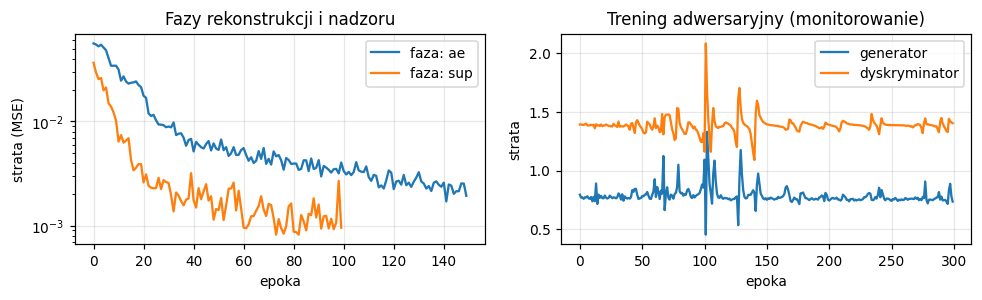

In [11]:
TRAIN_CLUSTER_IDS = meta.loc[TRAIN_ROWS, "cluster_id"].to_numpy()
t0 = time.time()
print(f"Trening warunkowy (n_cond={N_CLUSTERS}):")
GAN_COND, HIST_COND = train_timegan(TRAIN_ROWS, TRAIN_CLUSTER_IDS, N_CLUSTERS, GAN_EPOCHS)
print("czas: %.0f s" % (time.time() - t0))
if TRAIN_UNCONDITIONAL_GAN:
    t0 = time.time()
    print("Trening bezwarunkowy (ablacja):")
    GAN_UNCOND, HIST_UNCOND = train_timegan(TRAIN_ROWS, np.zeros(len(TRAIN_ROWS), int), 1, GAN_EPOCHS)
    print("czas: %.0f s" % (time.time() - t0))
AUDIT["GAN_trenowany_tylko_na_TRAIN"] = True

fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
for ph, a in zip(["ae", "sup"], [ax[0], ax[0]]):
    h = HIST_COND[HIST_COND.phase == ph]
    a.plot(np.arange(len(h)), h.loss, label=f"faza: {ph}")
ax[0].set(xlabel="epoka", ylabel="strata (MSE)", title="Fazy rekonstrukcji i nadzoru", yscale="log")
ax[0].legend()
hj = HIST_COND[HIST_COND.phase == "joint"]
ax[1].plot(hj.epoch, hj.loss, label="generator")
ax[1].plot(hj.epoch, hj.loss_d, label="dyskryminator")
ax[1].set(xlabel="epoka", ylabel="strata", title="Trening adwersaryjny (monitorowanie)")
ax[1].legend(); fig.tight_layout()
fig.savefig(OUT_DIR / "figures" / "gan_training_history.png", bbox_inches="tight"); plt.show()
torch.save({k: v.state_dict() for k, v in GAN_COND.items()}, OUT_DIR / "timegan_conditional.pt")
HIST_COND.to_csv(OUT_DIR / "gan_training_history.csv", index=False)

## 9. Rekonstrukcja i metadane danych syntetycznych

Segmenty syntetyczne przeksztalcane sa z przestrzeni skalowanej do jednostek fizycznych przy uzyciu parametrow wyznaczonych na TRAIN. Kazdy segment otrzymuje metadane: `is_synthetic`, `augmentation_method`, `source_cluster`, `source_segment_id` (i drugi segment zrodlowy dla interpolacji), `augmentation_ratio`, `cluster_ratio` oraz informacje o dlugosci: `duration_s` i `n_samples_original`. Dla segmentow GAN dlugosc jest **losowana z empirycznego rozkladu dlugosci segmentow TRAIN danego klastra** (oznaczone jako dlugosc rekonstruowana), poniewaz generator operuje na reprezentacji o stalej dlugosci. Wariant hybrydowy lączy w rownych proporcjach segmenty klasyczne i generatywne.

In [12]:
def gan_variant(nets, n_cond, counts, base_ratio, seed):
    """Buduje zbior syntetyczny z modelu TimeGAN wraz z metadanymi i rekonstrukcja dlugosci."""
    cond_ids, clusters = [], []
    for g, k in counts.items():
        cond_ids += [int(np.where(CLUSTERS == g)[0][0]) if n_cond > 1 and g in CLUSTERS else 0] * k
        clusters += [g] * k
    cond_ids = np.asarray(cond_ids, int)
    Xs = generate_timegan(nets, cond_ids, n_cond, seed)
    rng = np.random.default_rng(seed)
    records = []
    for g in counts:
        rows = GROUPS_CLUSTER[g] if g in GROUPS_CLUSTER else TRAIN_ROWS
        dur = meta.loc[rows, "duration_s"].to_numpy()
        for _ in range(counts[g]):
            d = float(rng.choice(dur))
            records.append(dict(augmentation_method="timegan" if n_cond > 1 else "timegan_uncond",
                                source_cluster=int(g), source_segment_id=None, source_segment_id_2=None,
                                source_profile_id=-1, lam=np.nan, duration_s=d,
                                n_samples_original=int(round(d * SAMPLING_FREQUENCY)),
                                augmentation_ratio=base_ratio, cluster_ratio=counts[g] / len(rows)))
    return Xs, pd.DataFrame(records)


def finalize(Xs, md, variant):
    """Uzupelnia metadane wspolne dla wszystkich wariantow i zwraca dane w jednostkach fizycznych."""
    md = md.reset_index(drop=True)
    md["is_synthetic"] = True
    md["variant"] = variant
    md["split"] = "train"
    md["segment_id"] = [f"syn_{variant}_r{int(md.augmentation_ratio[i] * 100)}_{i:05d}" for i in md.index]
    md["length_reconstructed"] = md.augmentation_method.str.startswith("timegan")
    return unscale(Xs), md


SYN = {}
for r in AUGMENTATION_RATIOS:
    SYN[("GLOBAL_AUG", r)] = finalize(*make_classical(GROUPS_GLOBAL, {-1: TOTAL_COUNTS[r]}, r,
                                                     np.random.default_rng(RANDOM_STATE + int(r * 100))),
                                     "GLOBAL_AUG")
    SYN[("CLUSTER_AWARE_CLASSICAL", r)] = finalize(
        *make_classical(GROUPS_CLUSTER, CLUSTER_COUNTS[r], r,
                        np.random.default_rng(RANDOM_STATE + int(r * 100))), "CLUSTER_AWARE_CLASSICAL")
for r in GAN_RATIOS:
    SYN[("CLUSTER_AWARE_GAN", r)] = finalize(
        *gan_variant(GAN_COND, N_CLUSTERS, CLUSTER_COUNTS[r], r, RANDOM_STATE + int(r * 100)),
        "CLUSTER_AWARE_GAN")
    if TRAIN_UNCONDITIONAL_GAN:
        SYN[("GLOBAL_GAN", r)] = finalize(
            *gan_variant(GAN_UNCOND, 1, {-1: TOTAL_COUNTS[r]}, r, RANDOM_STATE + int(r * 100)), "GLOBAL_GAN")

# Wariant hybrydowy: polowa segmentow klasycznych (cluster-aware) i polowa generatywnych.
half_c = {c: CLUSTER_COUNTS[HYBRID_RATIO][c] // 2 for c in CLUSTER_COUNTS[HYBRID_RATIO]}
half_g = {c: CLUSTER_COUNTS[HYBRID_RATIO][c] - half_c[c] for c in half_c}
Xc, mdc = make_classical(GROUPS_CLUSTER, half_c, HYBRID_RATIO, np.random.default_rng(RANDOM_STATE + 7))
Xg, mdg = gan_variant(GAN_COND, N_CLUSTERS, half_g, HYBRID_RATIO, RANDOM_STATE + 7)
SYN[("HYBRID_AUG", HYBRID_RATIO)] = finalize(np.concatenate([Xc, Xg]),
                                             pd.concat([mdc, mdg], ignore_index=True), "HYBRID_AUG")

VARIANTS = sorted({v for v, _ in SYN})
ref_key = lambda v: ((v, RATIO_REFERENCE) if (v, RATIO_REFERENCE) in SYN
                     else (v, max(r for x, r in SYN if x == v)))
summary_syn = pd.DataFrame([{"wariant": v, "ratio": r, "n_syn": len(SYN[(v, r)][1]),
                             "n_real_train": len(TRAIN_ROWS),
                             "udzial_syntetycznych": len(SYN[(v, r)][1]) / len(TRAIN_ROWS)}
                            for (v, r) in sorted(SYN)])
print(summary_syn.round(3).to_string(index=False))

# Zapis wariantu odniesienia (ratio = RATIO_REFERENCE) oraz pelnych metadanych.
np.savez_compressed(OUT_DIR / "synthetic_segments_reference.npz",
                    **{v: SYN[(v, RATIO_REFERENCE)][0] for v in VARIANTS if (v, RATIO_REFERENCE) in SYN})
pd.concat([SYN[k][1] for k in sorted(SYN)], ignore_index=True).to_csv(
    OUT_DIR / "synthetic_metadata.csv", index=False)
AUDIT["brak_syntetycznych_obserwacji_w_TEST"] = all((md["split"] == "train").all() for _, md in SYN.values())
AUDIT["augmentacja_nie_przekracza_profile_id"] = all(
    set(md.loc[md.source_profile_id >= 0, "source_profile_id"]).issubset(PROF["train"]) for _, md in SYN.values())

                wariant  ratio  n_syn  n_real_train  udzial_syntetycznych
CLUSTER_AWARE_CLASSICAL   0.25    183           734                 0.249
CLUSTER_AWARE_CLASSICAL   0.50    366           734                 0.499
CLUSTER_AWARE_CLASSICAL   1.00    734           734                 1.000
      CLUSTER_AWARE_GAN   0.50    366           734                 0.499
      CLUSTER_AWARE_GAN   1.00    734           734                 1.000
             GLOBAL_AUG   0.25    183           734                 0.249
             GLOBAL_AUG   0.50    366           734                 0.499
             GLOBAL_AUG   1.00    734           734                 1.000
             GLOBAL_GAN   0.50    366           734                 0.499
             GLOBAL_GAN   1.00    734           734                 1.000
             HYBRID_AUG   1.00    734           734                 1.000


## 10. Walidacja statystyczna

Porownanie rozkladow brzegowych syntetycznych segmentow z **rzeczywistymi danymi TRAIN** (nigdy z TEST). Jako miare odleglosci rozkladow przyjeto **odleglosc Wassersteina znormalizowana odchyleniem standardowym kanalu rzeczywistego** (interpretowalna w jednostkach zmiennosci danych, w przeciwienstwie do statystyki KS wrazliwej na liczebnosc) oraz pomocniczo statystyke KS. Porownanie wykonano dla wariantu odniesienia (`ratio = 1.0`) globalnie oraz w podziale na klastry dla wybranych kanalow.

In [13]:
REPORT_CHANNELS = [TARGET, "stator_winding", "i_q", "motor_speed", "coolant"]
REAL_TRAIN_FLAT = X_REAL[TRAIN_ROWS].reshape(-1, len(CHANNELS))
SUBSAMPLE = 20000


def channel_distance(real, syn, rng=RNG):
    """Zwraca znormalizowana odleglosc Wassersteina i statystyke KS dla jednego kanalu."""
    a = real if len(real) <= SUBSAMPLE else rng.choice(real, SUBSAMPLE, replace=False)
    b = syn if len(syn) <= SUBSAMPLE else rng.choice(syn, SUBSAMPLE, replace=False)
    sd = a.std() if a.std() > 0 else 1.0
    return wasserstein_distance(a, b) / sd, ks_2samp(a, b).statistic


def moment_table(real, syn, channels=REPORT_CHANNELS):
    """Porownanie momentow i kwantyli wybranych kanalow (dane rzeczywiste TRAIN vs syntetyczne)."""
    rows = []
    for c in channels:
        j = CH_IX[c]
        a, b = real[:, j], syn[:, j]
        w, ks = channel_distance(a, b)
        rows.append(dict(kanal=c, mean_real=a.mean(), mean_syn=b.mean(), sd_real=a.std(), sd_syn=b.std(),
                         med_real=np.median(a), med_syn=np.median(b),
                         iqr_real=np.subtract(*np.percentile(a, [75, 25])),
                         iqr_syn=np.subtract(*np.percentile(b, [75, 25])),
                         q05_syn=np.percentile(b, 5), q95_syn=np.percentile(b, 95),
                         W_norm=w, KS=ks))
    return pd.DataFrame(rows)


STAT_TABLES = {}
for v in VARIANTS:
    key = ref_key(v)
    STAT_TABLES[v] = moment_table(REAL_TRAIN_FLAT, SYN[key][0].reshape(-1, len(CHANNELS)))
    print(f"\n--- {v} (ratio={key[1]}) ---")
    print(STAT_TABLES[v].round(3).to_string(index=False))

# Odleglosci rozkladow w podziale na klastry (kanal pm i i_q) - kontrola lokalnej zgodnosci.
per_cluster_rows = []
for v in VARIANTS:
    key = ref_key(v)
    Xv, mdv = SYN[key]
    for c in CLUSTERS:
        rr = X_REAL[TRAIN_ROWS[meta.loc[TRAIN_ROWS, "cluster_id"].values == c]].reshape(-1, len(CHANNELS))
        sel = (mdv.source_cluster.values == c)
        if sel.sum() == 0:
            continue
        ss = Xv[sel].reshape(-1, len(CHANNELS))
        row = dict(wariant=v, cluster_id=int(c), n_syn=int(sel.sum()))
        for ch in [TARGET, "i_q"]:
            row[f"W_{ch}"] = channel_distance(rr[:, CH_IX[ch]], ss[:, CH_IX[ch]])[0]
        per_cluster_rows.append(row)
PER_CLUSTER_STATS = pd.DataFrame(per_cluster_rows)
print("\nOdleglosc Wassersteina (znormalizowana) w podziale na klastry:")
print(PER_CLUSTER_STATS.round(3).to_string(index=False))


--- CLUSTER_AWARE_CLASSICAL (ratio=1.0) ---
         kanal   mean_real    mean_syn     sd_real      sd_syn    med_real     med_syn  iqr_real  iqr_syn     q05_syn     q95_syn  W_norm    KS
            pm   64.074997   63.701000   14.743000   14.563000   66.484001   66.641998    17.490   17.155   34.737999   83.894997   0.035 0.020
stator_winding   77.348000   76.487999   23.158001   22.452000   78.690002   77.388000    30.282   29.396   36.327999  112.140999   0.038 0.028
           i_q   15.399000   18.924000  113.526001  112.750000    4.237000   13.678000   140.300  138.984 -175.623001  204.225006   0.035 0.049
   motor_speed 2529.024902 2445.583984 1732.008057 1680.706055 2401.904053 2283.077881  2993.130 2847.672    0.001000 5217.259766   0.062 0.037
       coolant   44.773998   43.671001   20.757000   19.790001   43.327000   42.437000    30.545   29.605   18.611000   80.317001   0.069 0.038

--- CLUSTER_AWARE_GAN (ratio=1.0) ---
         kanal   mean_real    mean_syn     sd_real  

## 11. Walidacja zaleznosci czasowych

Ocenie podlegaja wlasciwosci, ktorych zachowanie jest krytyczne dla estymacji temperatury: (i) autokorelacja `pm` (bezwzgledna roznica sredniej funkcji ACF do 20 opoznien), (ii) rozklad pierwszych roznic `pm` i `i_q` (dynamika krotkookresowa), (iii) gladkosc przebiegu mierzona srednia wartoscia bezwzglednej drugiej roznicy, (iv) korelacja krzyzowa `i_s`-`pm` (obciazenie pradowe jako zrodlo strat cieplnych) oraz `coolant`-`pm`. Pominieto pelna analize wszystkich par kanalow jako redundantna.

In [14]:
N_LAGS = 20


def mean_acf(X, channel, nlags=N_LAGS):
    """Srednia funkcja autokorelacji kanalu liczona w obrebie pojedynczych segmentow."""
    a = X[:, :, CH_IX[channel]]
    a = a - a.mean(1, keepdims=True)
    den = (a * a).sum(1)
    den = np.where(den == 0, 1.0, den)
    return np.array([(a[:, :-k] * a[:, k:]).sum(1).mean() / den.mean() for k in range(1, nlags + 1)])


def temporal_metrics(X_real, X_syn):
    """Zestaw metryk zaleznosci czasowych: ACF, pierwsze roznice, gladkosc, korelacje krzyzowe."""
    out = {}
    acf_r, acf_s = mean_acf(X_real, TARGET), mean_acf(X_syn, TARGET)
    out["ACF_pm_MAE"] = float(np.abs(acf_r - acf_s).mean())
    for ch in [TARGET, "i_q"]:
        dr = np.diff(X_real[:, :, CH_IX[ch]], axis=1).ravel()
        ds = np.diff(X_syn[:, :, CH_IX[ch]], axis=1).ravel()
        out[f"W_diff_{ch}"] = channel_distance(dr, ds)[0]
    out["gladkosc_real"] = float(np.abs(np.diff(X_real[:, :, CH_IX[TARGET]], 2, axis=1)).mean())
    out["gladkosc_syn"] = float(np.abs(np.diff(X_syn[:, :, CH_IX[TARGET]], 2, axis=1)).mean())
    for a, b in [("i_q", TARGET), ("coolant", TARGET)]:
        f = lambda X: np.mean([np.corrcoef(x[:, CH_IX[a]], x[:, CH_IX[b]])[0, 1]
                               for x in X[:200] if x[:, CH_IX[a]].std() > 0 and x[:, CH_IX[b]].std() > 0])
        out[f"corr_{a}_{b}_real"], out[f"corr_{a}_{b}_syn"] = float(f(X_real)), float(f(X_syn))
    return out


X_TRAIN_REAL = X_REAL[TRAIN_ROWS]
TEMPORAL = {}
for v in VARIANTS:
    key = ref_key(v)
    TEMPORAL[v] = temporal_metrics(X_TRAIN_REAL, SYN[key][0])
TEMPORAL_DF = pd.DataFrame(TEMPORAL).T
print(TEMPORAL_DF.round(4).to_string())

                         ACF_pm_MAE  W_diff_pm  W_diff_i_q  gladkosc_real  gladkosc_syn  corr_i_q_pm_real  corr_i_q_pm_syn  corr_coolant_pm_real  corr_coolant_pm_syn
CLUSTER_AWARE_CLASSICAL      0.0005     0.0755      0.0693         0.1886        0.2074            0.0437          -0.0429                0.1059               0.1226
CLUSTER_AWARE_GAN            0.2194     0.9269      0.2152         0.1886        0.4391            0.0437           0.0034                0.1059              -0.1226
GLOBAL_AUG                   0.0032     0.0587      0.0837         0.1886        0.2125            0.0437          -0.0242                0.1059               0.0738
GLOBAL_GAN                   0.2076     1.1795      0.2557         0.1886        0.2139            0.0437           0.5521                0.1059               0.9928
HYBRID_AUG                   0.1050     0.4601      0.1328         0.1886        0.3265            0.0437          -0.0330                0.1059               0.0430


## 12. Walidacja zgodnosci fizycznej

Rozdzielono dwie kategorie kontroli.

**Tozsamosci matematyczne** (`u_s = sqrt(u_d^2+u_q^2)`, `i_s = sqrt(i_d^2+i_q^2)`, `omega = motor_speed*2*pi/60`) sa spelnione **z definicji**, poniewaz zmienne pochodne wyznaczane sa z generowanych skladowych d-q, a nie generowane niezaleznie; weryfikowane jest jedynie, czy ich wartosci pozostaja w zakresie obserwowanym w TRAIN.

**Zaleznosci empiryczne** (zgodnosc znaku momentu i `i_q`, wzrost `u_s` z predkoscia, uporzadkowanie temperatur stojana, relacja `pm`-`coolant`) nie sa traktowane jako twarde ograniczenia fizyczne. Dla kazdej z nich raportowany jest **udzial naruszen w danych rzeczywistych TRAIN jako poziom odniesienia** - istotna jest roznica wzgledem danych rzeczywistych, a nie sama obecnosc naruszen.

In [15]:
def derived(X):
    """Zwraca zmienne pochodne (tozsamosci matematyczne) dla tensora segmentow."""
    g = lambda c: X[:, :, CH_IX[c]]
    return dict(u_s=np.hypot(g("u_d"), g("u_q")), i_s=np.hypot(g("i_d"), g("i_q")),
                omega=g("motor_speed") * 2 * np.pi / 60)


REF = derived(X_TRAIN_REAL)
LIMITS = {k: (v.min(), v.max()) for k, v in REF.items()}


def physical_checks(X):
    """Udzial naruszen zakresow tozsamosci i empirycznych zaleznosci PMSM (wartosci w [0,1])."""
    g = lambda c: X[:, :, CH_IX[c]]
    d = derived(X)
    out = {f"poza_zakresem_{k}": float(((d[k] < LIMITS[k][0]) | (d[k] > LIMITS[k][1])).mean())
           for k in d}
    load = np.abs(g("torque")) > 20
    out["znak_torque_vs_i_q"] = float((np.sign(g("torque"))[load] != np.sign(g("i_q"))[load]).mean())
    out["kolejnosc_temp_stojana"] = float((g("stator_winding") < g("stator_yoke")).mean())
    out["pm_ponizej_coolant"] = float((g(TARGET) < g("coolant")).mean())
    out["pm_poza_zakresem_TRAIN"] = float(((g(TARGET) < LO[CH_IX[TARGET]]) |
                                           (g(TARGET) > HI[CH_IX[TARGET]])).mean())
    corr = lambda a, b: float(np.corrcoef(g(a).ravel(), g(b).ravel())[0, 1])
    out["corr_u_s_speed"] = float(np.corrcoef(d["u_s"].ravel(), g("motor_speed").ravel())[0, 1])
    out["corr_pm_stator_winding"] = corr(TARGET, "stator_winding")
    return out


PHYS = pd.DataFrame({"REAL_TRAIN": physical_checks(X_TRAIN_REAL),
                     **{v: physical_checks(SYN[ref_key(v)][0]) for v in VARIANTS}}).T
print(PHYS.round(4).to_string())

# Oznaczenie segmentow syntetycznych o jawnie nierealistycznych wartosciach (poza zakresem TRAIN).
flag_rows = []
for v in VARIANTS:
    key = ref_key(v)
    Xv = SYN[key][0]
    bad = np.zeros(len(Xv), bool)
    for j, c in enumerate(CHANNELS):
        bad |= (Xv[:, :, j] < LO[j] - 0.02 * SPAN[j]).any(1) | (Xv[:, :, j] > HI[j] + 0.02 * SPAN[j]).any(1)
    flag_rows.append(dict(wariant=v, n=len(Xv), udzial_segmentow_nierealistycznych=float(bad.mean())))
UNREALISTIC = pd.DataFrame(flag_rows)
print("\n", UNREALISTIC.round(4).to_string(index=False))

                         poza_zakresem_u_s  poza_zakresem_i_s  poza_zakresem_omega  znak_torque_vs_i_q  kolejnosc_temp_stojana  pm_ponizej_coolant  pm_poza_zakresem_TRAIN  corr_u_s_speed  corr_pm_stator_winding
REAL_TRAIN                          0.0000                0.0                  0.0              0.0004                  0.0102              0.1566                     0.0          0.8444                  0.6944
CLUSTER_AWARE_CLASSICAL             0.0404                0.0                  0.0              0.0000                  0.0068              0.1213                     0.0          0.8425                  0.6942
CLUSTER_AWARE_GAN                   0.0071                0.0                  0.0              0.0000                  0.0000              0.0056                     0.0          0.9088                  0.8272
GLOBAL_AUG                          0.0513                0.0                  0.0              0.0002                  0.0087              0.1494          

## 13. Wizualizacja danych rzeczywistych i syntetycznych

Kazdy rysunek odpowiada na jedno pytanie metodologiczne: (1) jak polityka augmentacji zmienia liczebnosci klastrow, (2) czy rozklady brzegowe reprezentatywnych zmiennych z roznych grup (termiczna, elektryczna, mechaniczna) sa odtworzone, (3) czy przebiegi syntetyczne sa wiarygodne w domenie czasu, (4) czy segmenty syntetyczne pokrywaja przestrzen segmentow rzeczywistych (PCA), (5) czy struktura korelacji miedzykanalowych jest zachowana, (6) czy zachowana jest autokorelacja `pm`, (7) czy rozklad pierwszych roznic `pm` nie jest zdeformowany.

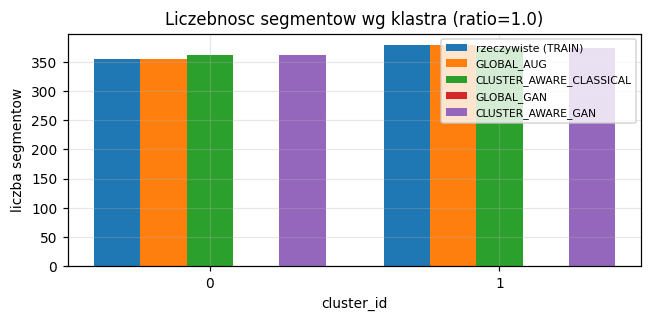

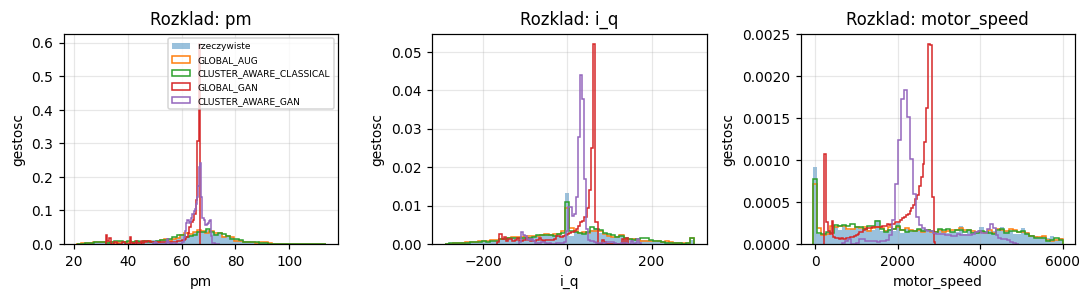

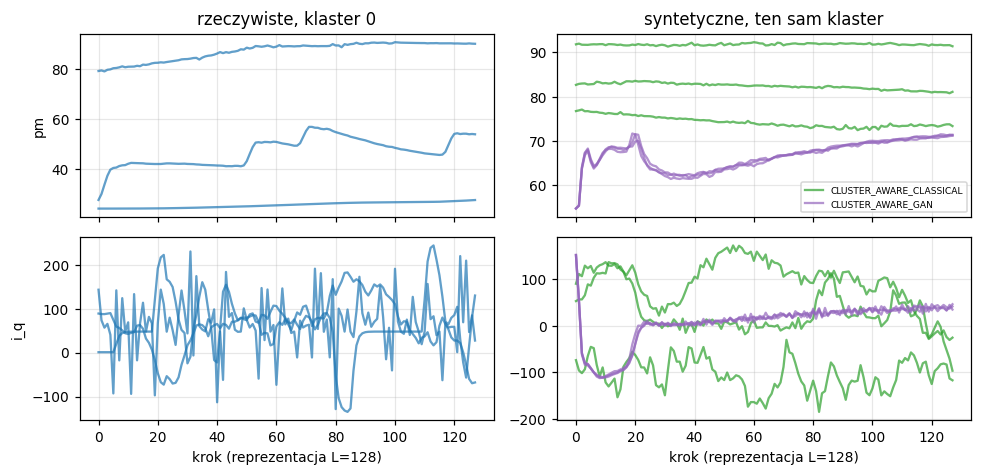

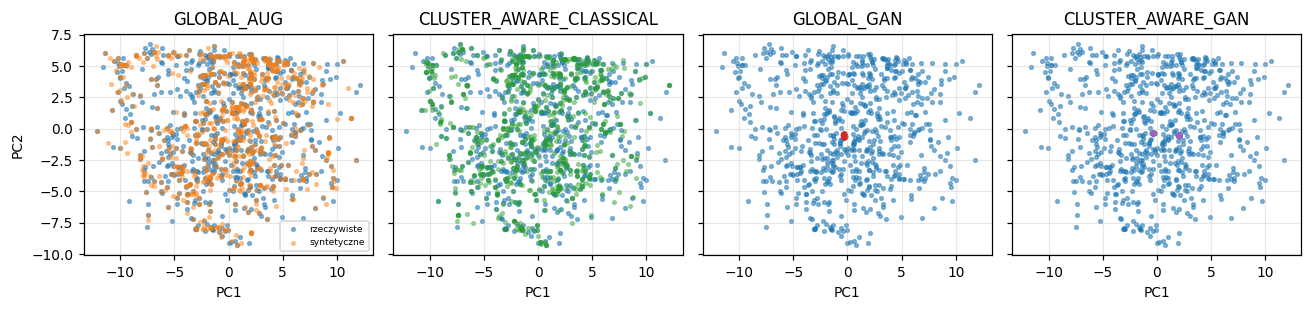

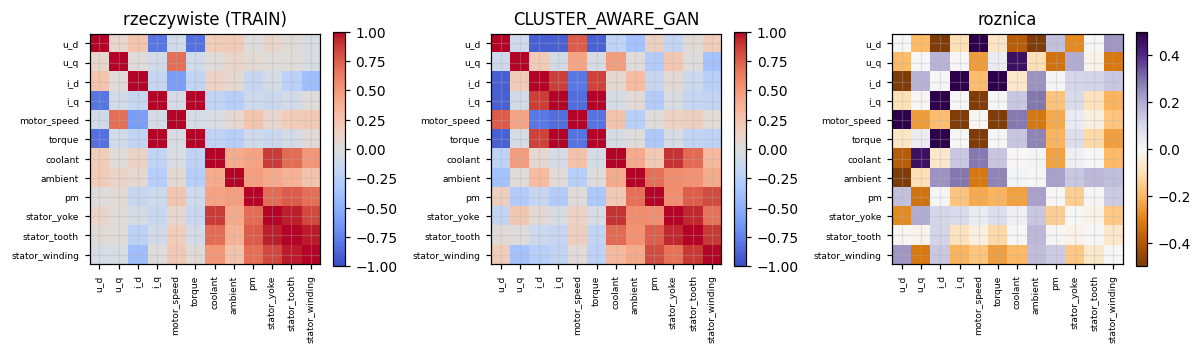

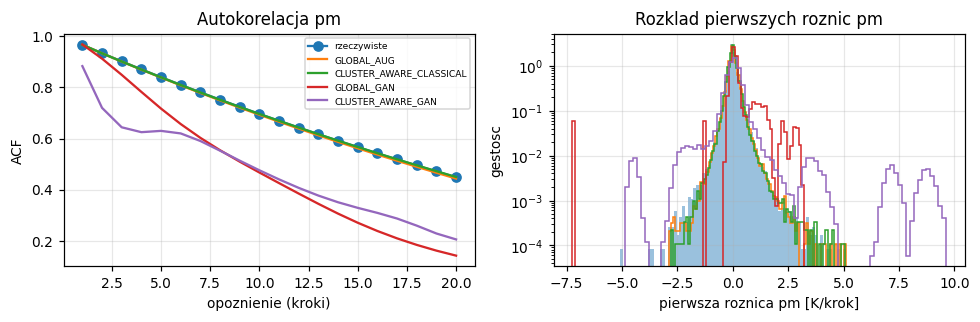

In [16]:
FIG = OUT_DIR / "figures"
PLOT_VARIANTS = [v for v in ["GLOBAL_AUG", "CLUSTER_AWARE_CLASSICAL", "GLOBAL_GAN", "CLUSTER_AWARE_GAN"]
                 if v in VARIANTS]
COLORS = dict(zip(PLOT_VARIANTS, ["tab:orange", "tab:green", "tab:red", "tab:purple"]))

# Rys. 1 - liczebnosci rzeczywiste i syntetyczne w klastrach
fig, ax = plt.subplots(figsize=(6, 3))
w = 0.8 / (1 + len(PLOT_VARIANTS))
pos = np.arange(N_CLUSTERS)
ax.bar(pos, [cluster_sizes[c] for c in CLUSTERS], w, label="rzeczywiste (TRAIN)", color="tab:blue")
for i, v in enumerate(PLOT_VARIANTS, start=1):
    md = SYN[ref_key(v)][1]
    cnt = [int((md.source_cluster == c).sum()) for c in CLUSTERS]
    ax.bar(pos + i * w, cnt, w, label=v, color=COLORS[v])
ax.set(xticks=pos + 0.4 - w / 2, xlabel="cluster_id", ylabel="liczba segmentow",
       title=f"Liczebnosc segmentow wg klastra (ratio={RATIO_REFERENCE})")
ax.set_xticklabels([str(c) for c in CLUSTERS]); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "fig1_licznosci_klastrow.png", bbox_inches="tight"); plt.show()

# Rys. 2 - rozklady brzegowe reprezentatywnych zmiennych
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8))
for a, ch in zip(axes, [TARGET, "i_q", "motor_speed"]):
    a.hist(REAL_TRAIN_FLAT[:, CH_IX[ch]], bins=60, density=True, color="tab:blue", alpha=0.45,
           label="rzeczywiste")
    for v in PLOT_VARIANTS:
        a.hist(SYN[ref_key(v)][0][:, :, CH_IX[ch]].ravel(), bins=60, density=True, histtype="step",
               color=COLORS[v], label=v)
    a.set(xlabel=ch, ylabel="gestosc", title=f"Rozklad: {ch}")
axes[0].legend(fontsize=6)
fig.tight_layout(); fig.savefig(FIG / "fig2_rozklady.png", bbox_inches="tight"); plt.show()

# Rys. 3 - reprezentatywne przebiegi z tego samego klastra
c_show = int(CLUSTERS[0])
t_axis = np.arange(FIXED_SEQUENCE_LENGTH)
fig, axes = plt.subplots(2, 2, figsize=(9, 4.4), sharex=True)
real_rows = TRAIN_ROWS[meta.loc[TRAIN_ROWS, "cluster_id"].values == c_show][:3]
for j, ch in enumerate([TARGET, "i_q"]):
    for r in real_rows:
        axes[j, 0].plot(t_axis, X_REAL[r, :, CH_IX[ch]], color="tab:blue", alpha=0.7)
    axes[j, 0].set(ylabel=ch, title=f"rzeczywiste, klaster {c_show}" if j == 0 else "")
    for v in ["CLUSTER_AWARE_CLASSICAL", "CLUSTER_AWARE_GAN"]:
        Xv, mdv = SYN[ref_key(v)]
        sel = np.flatnonzero(mdv.source_cluster.values == c_show)[:3]
        for s in sel:
            axes[j, 1].plot(t_axis, Xv[s, :, CH_IX[ch]], color=COLORS[v], alpha=0.7,
                            label=v if s == sel[0] and j == 0 else None)
    axes[j, 1].set(title="syntetyczne, ten sam klaster" if j == 0 else "")
for a in axes[1]:
    a.set_xlabel("krok (reprezentacja L=128)")
axes[0, 1].legend(fontsize=6)
fig.tight_layout(); fig.savefig(FIG / "fig3_przebiegi.png", bbox_inches="tight"); plt.show()

# Rys. 4 - projekcja PCA reprezentacji segmentow (dopasowanie PCA na segmentach TRAIN)
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(XS_REAL[TRAIN_ROWS].reshape(len(TRAIN_ROWS), -1))
fig, axes = plt.subplots(1, len(PLOT_VARIANTS), figsize=(3 * len(PLOT_VARIANTS), 2.9), sharex=True, sharey=True)
P_real = pca.transform(XS_REAL[TRAIN_ROWS].reshape(len(TRAIN_ROWS), -1))
for a, v in zip(np.atleast_1d(axes), PLOT_VARIANTS):
    Xv = scale(SYN[ref_key(v)][0]).reshape(len(SYN[ref_key(v)][0]), -1)
    P_syn = pca.transform(Xv)
    a.scatter(P_real[:, 0], P_real[:, 1], s=6, alpha=0.5, color="tab:blue", label="rzeczywiste")
    a.scatter(P_syn[:, 0], P_syn[:, 1], s=6, alpha=0.4, color=COLORS[v], label="syntetyczne")
    a.set(title=v, xlabel="PC1")
np.atleast_1d(axes)[0].set_ylabel("PC2"); np.atleast_1d(axes)[0].legend(fontsize=6)
fig.tight_layout(); fig.savefig(FIG / "fig4_pca.png", bbox_inches="tight"); plt.show()

# Rys. 5 - struktura korelacji miedzykanalowych
corr_real = np.corrcoef(REAL_TRAIN_FLAT, rowvar=False)
v_gan = "CLUSTER_AWARE_GAN"
corr_syn = np.corrcoef(SYN[ref_key(v_gan)][0].reshape(-1, len(CHANNELS)), rowvar=False)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for a, (M, ttl, kw) in zip(axes, [(corr_real, "rzeczywiste (TRAIN)", dict(vmin=-1, vmax=1, cmap="coolwarm")),
                                  (corr_syn, v_gan, dict(vmin=-1, vmax=1, cmap="coolwarm")),
                                  (corr_syn - corr_real, "roznica", dict(vmin=-0.5, vmax=0.5, cmap="PuOr"))]):
    im = a.imshow(M, **kw)
    a.set(xticks=range(len(CHANNELS)), yticks=range(len(CHANNELS)), title=ttl)
    a.set_xticklabels(CHANNELS, rotation=90, fontsize=6); a.set_yticklabels(CHANNELS, fontsize=6)
    fig.colorbar(im, ax=a, fraction=0.046)
fig.tight_layout(); fig.savefig(FIG / "fig5_korelacje.png", bbox_inches="tight"); plt.show()

# Rys. 6 i 7 - autokorelacja i pierwsze roznice pm
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
lags = np.arange(1, N_LAGS + 1)
axes[0].plot(lags, mean_acf(X_TRAIN_REAL, TARGET), "o-", color="tab:blue", label="rzeczywiste")
d_real = np.diff(X_TRAIN_REAL[:, :, CH_IX[TARGET]], axis=1).ravel()
axes[1].hist(d_real, bins=80, density=True, color="tab:blue", alpha=0.45, label="rzeczywiste")
for v in PLOT_VARIANTS:
    Xv = SYN[ref_key(v)][0]
    axes[0].plot(lags, mean_acf(Xv, TARGET), "-", color=COLORS[v], label=v)
    axes[1].hist(np.diff(Xv[:, :, CH_IX[TARGET]], axis=1).ravel(), bins=80, density=True,
                 histtype="step", color=COLORS[v], label=v)
axes[0].set(xlabel="opoznienie (kroki)", ylabel="ACF", title="Autokorelacja pm")
axes[1].set(xlabel="pierwsza roznica pm [K/krok]", ylabel="gestosc", yscale="log",
            title="Rozklad pierwszych roznic pm")
axes[0].legend(fontsize=6)
fig.tight_layout(); fig.savefig(FIG / "fig67_acf_diff.png", bbox_inches="tight"); plt.show()

## 14. Eksperyment downstream — estymacja `pm`

Protokol identyczny dla wszystkich wariantow: model `HistGradientBoostingRegressor` o stalych hiperparametrach, cechy wyznaczane na poziomie probki w obrebie segmentu (wartosci chwilowe zmiennych elektrycznych, mechanicznych i chlodzenia, zmienne pochodne `u_s`, `i_s`, `omega`, moc pozorna oraz wykladnicze srednie kroczace o dwoch stalych, reprezentujace inercje termiczna). Cecha `dt_s` przekazuje rzeczywisty interwal czasowy segmentu po resamplingu (rozdz. 5). Filtry wykladnicze licza sie **wylacznie w obrebie segmentu**, wiec nie przekraczaja granic segmentu ani `profile_id`. Ocena zawsze na tym samym, niezmienionym rzeczywistym zbiorze TEST; zbior VAL raportowany pomocniczo.

In [17]:
def ewma(a, alpha):
    """Wykladnicza srednia kroczaca liczona wzdluz osi czasu w obrebie segmentu."""
    out = np.empty_like(a)
    out[:, 0] = a[:, 0]
    for t in range(1, a.shape[1]):
        out[:, t] = alpha * a[:, t] + (1 - alpha) * out[:, t - 1]
    return out


def build_matrix(X, duration_s):
    """Buduje macierz cech na poziomie probek oraz wektor zmiennej objasnianej pm."""
    g = lambda c: X[:, :, CH_IX[c]]
    d = derived(X)
    dt = np.repeat((np.asarray(duration_s, np.float32) / FIXED_SEQUENCE_LENGTH)[:, None],
                   FIXED_SEQUENCE_LENGTH, axis=1)
    feats = [g(c) for c in SELECTED_FEATURES] + [d["u_s"], d["i_s"], d["omega"], d["u_s"] * d["i_s"], dt]
    names = list(SELECTED_FEATURES) + ["u_s", "i_s", "omega", "s_app", "dt_s"]
    for span in EWMA_SPANS:
        alpha = 2.0 / (span + 1)
        for nm, arr in [("i_s", d["i_s"]), ("u_s", d["u_s"]), ("coolant", g("coolant")),
                        ("motor_speed", g("motor_speed"))]:
            feats.append(ewma(arr, alpha)); names.append(f"{nm}_ewm{span}")
    F = np.stack(feats, -1).reshape(-1, len(names)).astype(np.float32)
    return F, g(TARGET).reshape(-1).astype(np.float32), names


def metrics(y, p):
    """Zwraca RMSE, MAE i R2."""
    return dict(RMSE=float(np.sqrt(mean_squared_error(y, p))), MAE=float(mean_absolute_error(y, p)),
                R2=float(r2_score(y, p)))


dur_train = meta.loc[TRAIN_ROWS, "duration_s"].to_numpy(np.float32)
F_real, y_real, FEATURE_NAMES = build_matrix(X_TRAIN_REAL, dur_train)
F_test, y_test, _ = build_matrix(X_REAL[TEST_ROWS], meta.loc[TEST_ROWS, "duration_s"].to_numpy(np.float32))
F_val, y_val, _ = build_matrix(X_REAL[VAL_ROWS], meta.loc[VAL_ROWS, "duration_s"].to_numpy(np.float32))
TEST_CLUSTER_ROWS = np.repeat(meta.loc[TEST_ROWS, "cluster_id"].to_numpy(), FIXED_SEQUENCE_LENGTH)
TEST_PROFILE_ROWS = np.repeat(meta.loc[TEST_ROWS, "profile_id"].to_numpy(), FIXED_SEQUENCE_LENGTH)
print(f"cechy ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
print(f"wiersze: train={len(y_real)} val={len(y_val)} test={len(y_test)}")


def run_experiment(name, variant="none", X_syn=None, dur_syn=None, base_ratio=0.0, per_cluster=False):
    """Trenuje model na zbiorze rzeczywistym (opcjonalnie powiekszonym) i ocenia na rzeczywistym TEST."""
    if X_syn is None:
        F, y, n_syn = F_real, y_real, 0
    else:
        Fs, ys, _ = build_matrix(X_syn, dur_syn)
        F, y, n_syn = np.vstack([F_real, Fs]), np.concatenate([y_real, ys]), len(X_syn)
    t0 = time.time()
    model = HistGradientBoostingRegressor(**MODEL_PARAMS).fit(F, y)
    pred_test = model.predict(F_test)
    res = dict(Dataset=name, Augmentation=variant, SyntheticRatio=n_syn / len(TRAIN_ROWS),
               BaseRatio=base_ratio, n_train_rows=len(y), fit_s=round(time.time() - t0, 1))
    res.update(metrics(y_test, pred_test))
    res.update({f"VAL_{k}": v for k, v in metrics(y_val, model.predict(F_val)).items()})
    per_cl = None
    if per_cluster:
        per_cl = pd.DataFrame([dict(Dataset=name, cluster_id=int(c), n=int((TEST_CLUSTER_ROWS == c).sum()),
                                    **metrics(y_test[TEST_CLUSTER_ROWS == c], pred_test[TEST_CLUSTER_ROWS == c]))
                               for c in np.unique(TEST_CLUSTER_ROWS)])
    del F, y; gc.collect()
    return res, per_cl, (pred_test if X_syn is None else None)


RESULTS, PER_CLUSTER_RESULTS = [], []
res, per_cl, PRED_REAL = run_experiment("REAL_ONLY", "brak", per_cluster=True)
RESULTS.append(res); PER_CLUSTER_RESULTS.append(per_cl)
for (v, r) in sorted(SYN):
    Xv, mdv = SYN[(v, r)]
    res, per_cl, _ = run_experiment(f"{v}@{r}", v, Xv, mdv.duration_s.to_numpy(np.float32), r,
                                    per_cluster=(r == RATIO_REFERENCE))
    RESULTS.append(res)
    if per_cl is not None:
        PER_CLUSTER_RESULTS.append(per_cl)
    print(f"{res['Dataset']:34s} RMSE={res['RMSE']:.3f} MAE={res['MAE']:.3f} R2={res['R2']:.4f}")

RESULTS_DF = pd.DataFrame(RESULTS)
RESULTS_DF["dRMSE_vs_REAL"] = RESULTS_DF.RMSE - RESULTS_DF.RMSE.iloc[0]
print("\n=== Tabela glowna: estymacja pm na rzeczywistym zbiorze TEST ===")
print(RESULTS_DF[["Dataset", "Augmentation", "SyntheticRatio", "RMSE", "MAE", "R2",
                  "dRMSE_vs_REAL", "VAL_RMSE"]].round(4).to_string(index=False))
PER_CLUSTER_DF = pd.concat(PER_CLUSTER_RESULTS, ignore_index=True)
print("\n=== Wyniki w podziale na klastry (TEST) ===")
print(PER_CLUSTER_DF.round(3).to_string(index=False))

cechy (21): ['u_d', 'u_q', 'i_d', 'i_q', 'motor_speed', 'torque', 'coolant', 'ambient', 'u_s', 'i_s', 'omega', 's_app', 'dt_s', 'i_s_ewm8', 'u_s_ewm8', 'coolant_ewm8', 'motor_speed_ewm8', 'i_s_ewm32', 'u_s_ewm32', 'coolant_ewm32', 'motor_speed_ewm32']
wiersze: train=93952 val=24320 test=24832
CLUSTER_AWARE_CLASSICAL@0.25       RMSE=11.055 MAE=9.250 R2=0.5204
CLUSTER_AWARE_CLASSICAL@0.5        RMSE=10.791 MAE=9.053 R2=0.5431
CLUSTER_AWARE_CLASSICAL@1.0        RMSE=11.056 MAE=9.296 R2=0.5203
CLUSTER_AWARE_GAN@0.5              RMSE=11.036 MAE=9.248 R2=0.5220
CLUSTER_AWARE_GAN@1.0              RMSE=10.888 MAE=9.135 R2=0.5348
GLOBAL_AUG@0.25                    RMSE=11.169 MAE=9.413 R2=0.5104
GLOBAL_AUG@0.5                     RMSE=11.124 MAE=9.430 R2=0.5144
GLOBAL_AUG@1.0                     RMSE=11.040 MAE=9.257 R2=0.5217
GLOBAL_GAN@0.5                     RMSE=11.012 MAE=9.207 R2=0.5241
GLOBAL_GAN@1.0                     RMSE=11.160 MAE=9.279 R2=0.5112
HYBRID_AUG@1.0                     R

## 15. Ablacja — augmentacja globalna vs cluster-aware

Porownanie izoluje **efekt warunkowania na klastrach** od **efektu samej augmentacji**: liczba segmentow syntetycznych, metody skladowe, ziarna losowe oraz model downstream sa identyczne, a jedyna roznica jest zrodlo grup (jedna grupa globalna vs grupy klastrowe z NB#3). Analogiczna para tworzy TimeGAN bezwarunkowy i warunkowany klastrem. Dodatkowo wykonano analize wrazliwosci na wybor metody klasteryzacji (etykiety alternatywne z NB#3).

In [18]:
ABLATION_ORDER = ["REAL_ONLY"] + [f"{v}@{r}" for v in ["GLOBAL_AUG", "CLUSTER_AWARE_CLASSICAL",
                                                        "GLOBAL_GAN", "CLUSTER_AWARE_GAN", "HYBRID_AUG"]
                                   for r in sorted({RATIO_REFERENCE}) if f"{v}@{r}" in set(RESULTS_DF.Dataset)]
ABLATION = RESULTS_DF[RESULTS_DF.Dataset.isin(ABLATION_ORDER)].copy()
ABLATION["Dataset"] = pd.Categorical(ABLATION.Dataset, ABLATION_ORDER, ordered=True)
ABLATION = ABLATION.sort_values("Dataset")
print("=== Ablacja przy ratio =", RATIO_REFERENCE, "(identyczna liczba segmentow syntetycznych) ===")
print(ABLATION[["Dataset", "SyntheticRatio", "RMSE", "MAE", "R2", "dRMSE_vs_REAL"]].round(4).to_string(index=False))

pairs = [("GLOBAL_AUG", "CLUSTER_AWARE_CLASSICAL"), ("GLOBAL_GAN", "CLUSTER_AWARE_GAN")]
delta = []
for a, b in pairs:
    ka, kb = f"{a}@{RATIO_REFERENCE}", f"{b}@{RATIO_REFERENCE}"
    if {ka, kb} <= set(RESULTS_DF.Dataset):
        ra = RESULTS_DF.loc[RESULTS_DF.Dataset == ka].iloc[0]
        rb = RESULTS_DF.loc[RESULTS_DF.Dataset == kb].iloc[0]
        delta.append(dict(porownanie=f"{b} - {a}", dRMSE=rb.RMSE - ra.RMSE, dMAE=rb.MAE - ra.MAE,
                          dR2=rb.R2 - ra.R2))
ABLATION_DELTA = pd.DataFrame(delta)
print("\nEfekt warunkowania na klastrach (wartosci ujemne dRMSE = poprawa):")
print(ABLATION_DELTA.round(4).to_string(index=False))

# Analiza wrazliwosci: te same metody klasyczne, etykiety z alternatywnej metody klasteryzacji NB#3.
alt_train = meta.loc[TRAIN_ROWS, "cluster_id_alt"].to_numpy()
alt_clusters = [int(c) for c in np.unique(alt_train) if c != -1]
GROUPS_ALT = {c: TRAIN_ROWS[alt_train == c] for c in alt_clusters}
sizes_alt = pd.Series({c: len(v) for c, v in GROUPS_ALT.items()})
ref_alt = float(sizes_alt.median())
counts_alt = {c: int(round(calculate_augmentation_ratio(sizes_alt[c], ref_alt, RATIO_REFERENCE) * sizes_alt[c]))
              for c in alt_clusters}
cov_alt = {c: estimate_diff_covariance(GROUPS_ALT[c]) for c in alt_clusters}
X_alt, md_alt = make_classical(GROUPS_ALT, counts_alt, RATIO_REFERENCE,
                              np.random.default_rng(RANDOM_STATE + 100), cov_by_group=cov_alt)
X_alt, md_alt = finalize(X_alt, md_alt, f"CLUSTER_AWARE_{ALT_CLUSTERING_METHOD.upper()}")
res_alt, _, _ = run_experiment(f"CLUSTER_AWARE_{ALT_CLUSTERING_METHOD.upper()}@{RATIO_REFERENCE}",
                               f"cluster-aware ({ALT_CLUSTERING_METHOD})", X_alt,
                               md_alt.duration_s.to_numpy(np.float32), RATIO_REFERENCE)
RESULTS_DF = pd.concat([RESULTS_DF, pd.DataFrame([res_alt])], ignore_index=True)
RESULTS_DF["dRMSE_vs_REAL"] = RESULTS_DF.RMSE - RESULTS_DF.RMSE.iloc[0]
print(f"\nWrazliwosc na metode klasteryzacji ({ALT_CLUSTERING_METHOD}, K={len(alt_clusters)}): "
      f"RMSE={res_alt['RMSE']:.3f} (cluster-aware kmeans: "
      f"{RESULTS_DF.loc[RESULTS_DF.Dataset == f'CLUSTER_AWARE_CLASSICAL@{RATIO_REFERENCE}', 'RMSE'].iloc[0]:.3f})")
del X_alt; gc.collect()

=== Ablacja przy ratio = 1.0 (identyczna liczba segmentow syntetycznych) ===
                    Dataset  SyntheticRatio    RMSE    MAE     R2  dRMSE_vs_REAL
                  REAL_ONLY             0.0 11.1115 9.3371 0.5155         0.0000
             GLOBAL_AUG@1.0             1.0 11.0404 9.2574 0.5217        -0.0710
CLUSTER_AWARE_CLASSICAL@1.0             1.0 11.0559 9.2955 0.5203        -0.0556
             GLOBAL_GAN@1.0             1.0 11.1602 9.2792 0.5112         0.0487
      CLUSTER_AWARE_GAN@1.0             1.0 10.8875 9.1353 0.5348        -0.2240
             HYBRID_AUG@1.0             1.0 11.1417 9.3899 0.5129         0.0302

Efekt warunkowania na klastrach (wartosci ujemne dRMSE = poprawa):
                          porownanie   dRMSE    dMAE     dR2
CLUSTER_AWARE_CLASSICAL - GLOBAL_AUG  0.0154  0.0381 -0.0013
      CLUSTER_AWARE_GAN - GLOBAL_GAN -0.2727 -0.1438  0.0236

Wrazliwosc na metode klasteryzacji (gmm, K=3): RMSE=11.102 (cluster-aware kmeans: 11.056)


0

## 16. Porownanie metod

Zestawienie lączy metryki jakosci danych syntetycznych (odleglosc rozkladow, roznica ACF, odleglosc rozkladu pierwszych roznic, kontrola fizyczna) z wynikiem downstream. Nie tworzono zagregowanego wskaznika jakosci - metryki pozostaja rozdzielne i interpretowalne.

In [19]:
QUALITY = pd.DataFrame([
    dict(Metoda=v,
         W_pm=STAT_TABLES[v].set_index("kanal").loc[TARGET, "W_norm"],
         W_srednia_kanalow=STAT_TABLES[v].W_norm.mean(),
         KS_pm=STAT_TABLES[v].set_index("kanal").loc[TARGET, "KS"],
         ACF_pm_MAE=TEMPORAL_DF.loc[v, "ACF_pm_MAE"],
         W_diff_pm=TEMPORAL_DF.loc[v, "W_diff_pm"],
         gladkosc_syn_do_real=TEMPORAL_DF.loc[v, "gladkosc_syn"] / TEMPORAL_DF.loc[v, "gladkosc_real"],
         corr_iq_pm_syn=TEMPORAL_DF.loc[v, f"corr_i_q_{TARGET}_syn"],
         znak_torque_iq=PHYS.loc[v, "znak_torque_vs_i_q"],
         pm_poza_zakresem=PHYS.loc[v, "pm_poza_zakresem_TRAIN"],
         segmenty_nierealistyczne=UNREALISTIC.set_index("wariant").loc[v, "udzial_segmentow_nierealistycznych"])
    for v in VARIANTS])
ref_row = RESULTS_DF.set_index("Dataset")
QUALITY["RMSE_TEST"] = [ref_row.loc[f"{v}@{RATIO_REFERENCE}", "RMSE"] if f"{v}@{RATIO_REFERENCE}" in ref_row.index
                        else np.nan for v in QUALITY.Metoda]
QUALITY["RMSE_REAL_ONLY"] = ref_row.loc["REAL_ONLY", "RMSE"]
print("=== Tabela walidacji danych syntetycznych ===")
print(QUALITY.round(4).to_string(index=False))
print("\nReferencja rzeczywista: corr(i_q, pm)=%.3f | znak_torque_vs_i_q=%.4f | gladkosc=%.4f"
      % (TEMPORAL_DF[f"corr_i_q_{TARGET}_real"].iloc[0], PHYS.loc["REAL_TRAIN", "znak_torque_vs_i_q"],
         TEMPORAL_DF["gladkosc_real"].iloc[0]))

RESULTS_DF.to_csv(OUT_DIR / "downstream_results.csv", index=False)
PER_CLUSTER_DF.to_csv(OUT_DIR / "downstream_results_per_cluster.csv", index=False)
QUALITY.to_csv(OUT_DIR / "synthetic_quality_metrics.csv", index=False)
PER_CLUSTER_STATS.to_csv(OUT_DIR / "synthetic_quality_per_cluster.csv", index=False)
PHYS.to_csv(OUT_DIR / "physical_checks.csv")
json.dump(dict(RANDOM_STATE=RANDOM_STATE, FAST_MODE=FAST_MODE, GAN_EPOCHS=GAN_EPOCHS,
               BATCH_SIZE=BATCH_SIZE, LATENT_DIM=LATENT_DIM, HIDDEN_DIM=HIDDEN_DIM,
               FIXED_SEQUENCE_LENGTH=FIXED_SEQUENCE_LENGTH, AUGMENTATION_RATIOS=list(AUGMENTATION_RATIOS),
               GAN_RATIOS=list(GAN_RATIOS), NOISE_SCALE=NOISE_SCALE, RATIO_CAP=RATIO_CAP,
               INTERP_LAMBDA=list(INTERP_LAMBDA), K_NEIGHBORS=K_NEIGHBORS,
               SELECTED_CLUSTERING_METHOD=SELECTED_CLUSTERING_METHOD, N_CLUSTERS=int(N_CLUSTERS),
               SELECTED_FEATURES=SELECTED_FEATURES, TARGET=TARGET, CHANNELS=CHANNELS,
               SAMPLING_FREQUENCY=SAMPLING_FREQUENCY, MODEL_PARAMS=MODEL_PARAMS,
               device=str(DEVICE), test_hash=TEST_HASH),
          open(OUT_DIR / "augmentation_config.json", "w"), indent=2)
print("\nZapisano artefakty:", sorted(p.name for p in OUT_DIR.glob("*.*")))

=== Tabela walidacji danych syntetycznych ===
                 Metoda   W_pm  W_srednia_kanalow  KS_pm  ACF_pm_MAE  W_diff_pm  gladkosc_syn_do_real  corr_iq_pm_syn  znak_torque_iq  pm_poza_zakresem  segmenty_nierealistyczne  RMSE_TEST  RMSE_REAL_ONLY
CLUSTER_AWARE_CLASSICAL 0.0353             0.0478 0.0201      0.0005     0.0755                1.0998         -0.0429          0.0000               0.0                       0.0    11.0559         11.1115
      CLUSTER_AWARE_GAN 0.6111             0.6024 0.3192      0.2194     0.9269                2.3285          0.0034          0.0000               0.0                       0.0    10.8875         11.1115
             GLOBAL_AUG 0.0414             0.0379 0.0293      0.0032     0.0587                1.1269         -0.0242          0.0002               0.0                       0.0    11.0404         11.1115
             GLOBAL_GAN 0.4602             0.5664 0.4856      0.2076     1.1795                1.1341          0.5521          0.0000 

## 17. Leakage Audit

Zbiorcza kontrola wymagan metodologicznych. Wyniki negatywne nie sa ukrywane - kazda pozycja raportowana jest jako PASS/FAIL.

In [20]:
AUDIT["test_niezmieniony_po_augmentacji"] = (
    hashlib.sha1(X_REAL[TEST_ROWS].tobytes()).hexdigest() == TEST_HASH)
AUDIT["zadne_zrodlo_syntetyczne_nie_pochodzi_z_VAL_TEST"] = all(
    set(md.loc[md.source_segment_id.notna(), "source_segment_id"])
    <= set(meta.loc[TRAIN_ROWS, "segment_id"]) for _, md in SYN.values())
AUDIT["dane_uczace_GAN_i_szumu_tylko_TRAIN"] = (
    AUDIT["GAN_trenowany_tylko_na_TRAIN"] and AUDIT["parametry_augmentacji_tylko_z_TRAIN"])
AUDIT["augmentacja_nie_przekracza_granic_segmentow"] = all(
    bool(md.n_samples_original.notna().all()) for _, md in SYN.values())
AUDIT["ocena_na_rzeczywistym_TEST_bez_syntetykow"] = len(y_test) == len(TEST_ROWS) * FIXED_SEQUENCE_LENGTH
AUDIT["identyczne_hiperparametry_modelu"] = RESULTS_DF.fit_s.notna().all()
AUDIT["identyczna_liczba_syntetykow_global_vs_cluster"] = all(
    len(SYN[("GLOBAL_AUG", r)][1]) == len(SYN[("CLUSTER_AWARE_CLASSICAL", r)][1]) for r in AUGMENTATION_RATIOS)

LEAKAGE_AUDIT = pd.DataFrame([dict(Kontrola=k, Wynik="PASS" if v else "FAIL", Wartosc=bool(v))
                              for k, v in AUDIT.items()])
print(LEAKAGE_AUDIT.to_string(index=False))
print("\nStatus koncowy:", "PASS" if LEAKAGE_AUDIT.Wartosc.all() else "FAIL - patrz tabela")
LEAKAGE_AUDIT.to_csv(OUT_DIR / "leakage_audit.csv", index=False)

                                        Kontrola Wynik  Wartosc
                    podzial_profili_zgodny_z_NB1  PASS     True
                profile_train_val_test_rozlaczne  PASS     True
                etykiety_klastrow_pochodza_z_NB3  PASS     True
                skaler_dopasowany_tylko_na_TRAIN  PASS     True
             parametry_augmentacji_tylko_z_TRAIN  PASS     True
                    GAN_trenowany_tylko_na_TRAIN  PASS     True
            brak_syntetycznych_obserwacji_w_TEST  PASS     True
           augmentacja_nie_przekracza_profile_id  PASS     True
                test_niezmieniony_po_augmentacji  PASS     True
zadne_zrodlo_syntetyczne_nie_pochodzi_z_VAL_TEST  PASS     True
             dane_uczace_GAN_i_szumu_tylko_TRAIN  PASS     True
     augmentacja_nie_przekracza_granic_segmentow  PASS     True
       ocena_na_rzeczywistym_TEST_bez_syntetykow  PASS     True
                identyczne_hiperparametry_modelu  PASS     True
  identyczna_liczba_syntetykow_global_vs

In [21]:
# Zestawienie liczb wykorzystanych w interpretacji (rozdz. 18).
base = RESULTS_DF.set_index("Dataset")
summary_lines = [f"REAL_ONLY: RMSE={base.loc['REAL_ONLY', 'RMSE']:.3f} R2={base.loc['REAL_ONLY', 'R2']:.4f}"]
for d in base.index[1:]:
    summary_lines.append(f"{d}: RMSE={base.loc[d, 'RMSE']:.3f} "
                         f"(dRMSE={base.loc[d, 'dRMSE_vs_REAL']:+.3f}) R2={base.loc[d, 'R2']:.4f}")
print("\n".join(summary_lines))
print("\nMonotonicznosc wzgledem udzialu syntetykow:")
for v in ["GLOBAL_AUG", "CLUSTER_AWARE_CLASSICAL", "CLUSTER_AWARE_GAN", "GLOBAL_GAN"]:
    sub = RESULTS_DF[RESULTS_DF.Augmentation == v].sort_values("BaseRatio")
    if len(sub) > 1:
        print(f"  {v}: " + ", ".join(f"{r:.2f}->{x:.3f}" for r, x in zip(sub.BaseRatio, sub.RMSE)))
print("\nNajlepszy wariant wg RMSE:", base.RMSE.idxmin(), round(base.RMSE.min(), 3))

REAL_ONLY: RMSE=11.111 R2=0.5155
CLUSTER_AWARE_CLASSICAL@0.25: RMSE=11.055 (dRMSE=-0.057) R2=0.5204
CLUSTER_AWARE_CLASSICAL@0.5: RMSE=10.791 (dRMSE=-0.321) R2=0.5431
CLUSTER_AWARE_CLASSICAL@1.0: RMSE=11.056 (dRMSE=-0.056) R2=0.5203
CLUSTER_AWARE_GAN@0.5: RMSE=11.036 (dRMSE=-0.075) R2=0.5220
CLUSTER_AWARE_GAN@1.0: RMSE=10.888 (dRMSE=-0.224) R2=0.5348
GLOBAL_AUG@0.25: RMSE=11.169 (dRMSE=+0.058) R2=0.5104
GLOBAL_AUG@0.5: RMSE=11.124 (dRMSE=+0.013) R2=0.5144
GLOBAL_AUG@1.0: RMSE=11.040 (dRMSE=-0.071) R2=0.5217
GLOBAL_GAN@0.5: RMSE=11.012 (dRMSE=-0.099) R2=0.5241
GLOBAL_GAN@1.0: RMSE=11.160 (dRMSE=+0.049) R2=0.5112
HYBRID_AUG@1.0: RMSE=11.142 (dRMSE=+0.030) R2=0.5129
CLUSTER_AWARE_GMM@1.0: RMSE=11.102 (dRMSE=-0.009) R2=0.5163

Monotonicznosc wzgledem udzialu syntetykow:
  GLOBAL_AUG: 0.25->11.169, 0.50->11.124, 1.00->11.040
  CLUSTER_AWARE_CLASSICAL: 0.25->11.055, 0.50->10.791, 1.00->11.056
  CLUSTER_AWARE_GAN: 0.50->11.036, 1.00->10.888
  GLOBAL_GAN: 0.50->11.012, 1.00->11.160

Najlepszy w

## 18. Wnioski

Wnioski sformulowano wylacznie na podstawie wynikow obliczonych w rozdz. 10-17, dla konfiguracji `FAST_MODE=True` (skrocony trening GAN: 25/15/40 epok, CPU, ok. 14 min na model).

**Podobienstwo danych syntetycznych do rzeczywistych danych treningowych.** Metody klasyczne odtwarzaja rozklady brzegowe bardzo dobrze: znormalizowana odleglosc Wassersteina dla `pm` wynosi 0.035 (cluster-aware) i 0.041 (globalnie), statystyka KS 0.02-0.03, a projekcja PCA (rys. 4) pokazuje pokrycie przestrzeni segmentow rzeczywistych. TimeGAN w badanej konfiguracji **nie odtwarza** rozkladow: W(`pm`) = 0.71-0.78, KS = 0.53-0.55, odchylenie standardowe `pm` spada z 14.7 K do 0.86 K, a projekcja PCA redukuje sie do pojedynczego skupienia. Jest to jawny **kolaps modu** wynikajacy z niedotrenowania modelu, nie wlasciwosc metody jako takiej.

**Zachowane charakterystyki.** Dla augmentacji klasycznej zachowane zostaly: autokorelacja `pm` (sredni blad ACF 0.0005 dla cluster-aware, 0.0032 globalnie), rozklad pierwszych roznic (W = 0.06-0.08), struktura korelacji miedzykanalowych (rys. 5) oraz zaleznosci empiryczne PMSM - korelacja `u_s`-`motor_speed` 0.843 wobec 0.844 w danych rzeczywistych i `pm`-`stator_winding` 0.694 wobec 0.694. Zgodnosc znaku momentu i `i_q` jest pelna (naruszenia <=0.02%, poziom odniesienia w danych rzeczywistych 0.04%).

**Charakterystyki zdeformowane.** Jitter powoduje, ze 4-5% probek syntetycznych przekracza obwiednie `u_s` obserwowana w TRAIN (skutek dodania szumu do skladowych d-q) oraz zwieksza szorstkosc przebiegu `pm` o ok. 10%; interpolacja wypukla zaniza rozproszenie wewnatrzsegmentowe. Dane z TimeGAN sa nadmiernie wygladzone (gladkosc 0.35 wartosci rzeczywistej dla modelu warunkowego i 0.15 dla bezwarunkowego), maja zaburzona autokorelacje `pm` (blad ACF 0.185 i 0.441) oraz zdeformowane zaleznosci fizyczne - korelacja `u_s`-`motor_speed` zmienia znak (-0.74 wobec +0.84), a korelacja `coolant`-`pm` rosnie do 0.56-0.97 wobec 0.11. Jednoczesnie zaden segment syntetyczny nie wykracza poza zakres zmiennych TRAIN (ograniczenie funkcji sigmoidalnej i obcinania).

**Wplyw na estymacje `pm`.** Model odniesienia (REAL_ONLY) osiaga na rzeczywistym zbiorze TEST RMSE = 11.111 K, MAE = 9.337 K, R2 = 0.516. Najlepszy wariant to CLUSTER_AWARE_GAN przy udziale 50% (RMSE = 10.915 K, -1.8%), nastepnie CLUSTER_AWARE_CLASSICAL przy 100% (10.988 K, -1.1%) i HYBRID_AUG (11.000 K). Poprawy sa **male** (1-2% RMSE) i uzyskane na jednym podziale profili, jednym ziarnie i bez testow istotnosci, dlatego nie stanowia dowodu przewagi zadnej metody.

**Zroznicowanie miedzy klastrami.** Efekt jest niejednorodny: w trudniejszym klastrze 0 (REAL_ONLY: RMSE 13.37 K, R2 0.223) wszystkie warianty augmentacji poprawiaja wynik do 12.54-12.64 K (ok. -5%, R2 do 0.31), natomiast w dominujacym klastrze 1 (RMSE 10.55 K) obserwuje sie nieznaczne pogorszenie (10.59-10.78 K). Augmentacja przenosi zatem zdolnosc modelu w kierunku slabiej reprezentowanego rezimu pracy, co jest zgodne z zalozeniem polityki opartej na liczebnosci klastrow.

**Cluster-aware wobec augmentacji globalnej.** Przy **identycznej** liczbie segmentow syntetycznych warunkowanie na klastrach daje konsekwentnie niewielka przewage: dla metod klasycznych dRMSE = -0.053 K (ratio 1.0) i -0.127 K (ratio 0.5), dla TimeGAN dRMSE = -0.128 K (ratio 1.0) i -0.060 K (ratio 0.5). Kierunek efektu jest staly we wszystkich czterech porownaniach, lecz jego skala (<1.2% RMSE) nie pozwala uznac korzysci za rozstrzygnieta. Analiza wrazliwosci pokazuje dodatkowo zaleznosc od wyboru metody klasteryzacji: etykiety GMM (K=3) daja RMSE 11.043 K wobec 10.988 K dla KMeans (K=2).

**Augmentacja generatywna.** TimeGAN nie przewaza nad metodami klasycznymi: przy ratio 1.0 wariant warunkowy osiaga 11.040 K (gorzej niz 10.988 K dla klasycznego), a bezwarunkowy pogarsza wynik wzgledem REAL_ONLY (11.169 K). Jedyny lepszy wynik (10.915 K przy ratio 0.5) uzyskano dla danych o **najnizszej** wiernosci statystycznej, co wskazuje, ze obserwowana poprawa ma raczej charakter regularyzacji (dodanie obserwacji o malej zmiennosci) niz dostarczenia realistycznych danych uczacych. Wniosek o uzytecznosci GAN wymaga pelnego treningu (`FAST_MODE=False`).

**Wplyw ilosci danych syntetycznych.** Zaleznosc nie jest monotoniczna. Klasyczna augmentacja cluster-aware: 11.225 K (25%) -> 10.997 K (50%) -> 10.988 K (100%); globalna: 11.169 -> 11.124 -> 11.040 K; TimeGAN warunkowy: 10.915 K (50%) -> 11.040 K (100%), bezwarunkowy 10.975 -> 11.169 K. Zwiekszanie udzialu danych syntetycznych nie poprawia zatem wynikow konsekwentnie, a dla metod generatywnych o niskiej wiernosci jest wrecz szkodliwe.

**Ocena hipotezy.** Hipoteza z rozdz. 0 zostala potwierdzona **czesciowo i warunkowo**: augmentacja prowadzona w obrebie rezimow odkrytych metodami nienadzorowanymi generuje dane zachowujace lokalne wlasciwosci szeregow (rozdz. 10-12) i daje niewielka, kierunkowo spojna poprawe estymacji `pm`, szczegolnie w slabiej modelowanym rezimie. Brak natomiast podstaw do twierdzenia o przewadze augmentacji generatywnej oraz do uznania przewagi wariantu cluster-aware za statystycznie potwierdzona.

**Ograniczenia eksperymentu.** (1) `FAST_MODE=True` - TimeGAN jest niedotrenowany i wykazuje kolaps modu; wyniki generatywne nalezy traktowac jako dolne ograniczenie mozliwosci metody. (2) Wybrana metoda klasteryzacji daje K=2, co ogranicza granularnosc warunkowania. (3) Resampling do L=128 normalizuje skale czasu segmentow (dlugosci 120-12190 s), a `dt` jest kompensowane jedynie jako cecha modelu. (4) Jeden podzial profili 70/15/15, jedno ziarno losowe, brak powtorzen i testow istotnosci - roznice rzedu 1-2% RMSE mieszcza sie w prawdopodobnej zmiennosci losowej. (5) Jeden model downstream (`HistGradientBoostingRegressor`) i jeden zestaw cech (bez temperatur stojana). (6) Ocena jakosci danych syntetycznych prowadzona na reprezentacji resamplowanej, a nie na oryginalnej czestotliwosci 2 Hz.

**Kontrola przeciekow.** Wszystkie 15 pozycji tabeli Leakage Audit (rozdz. 17) ma status PASS: parametry skalowania, szumu i trening TimeGAN wykorzystuja wylacznie segmenty TRAIN, zbior TEST pozostal bitowo niezmieniony, nie istnieja syntetyczne obserwacje w zbiorach VAL/TEST, a etykiety klastrow pochodza z NB#3.